# Example-23: Effect of systematic shift in scale calibration errors

In [1]:
# In this example effect of systematic shift in scale calibratin errors is illustrated
# Normaly, with <gxx> = <gyy> = 1 and <gxy> = <gyx> = 0, estimation of scales from ratio has no bias
# Similarly, this is true for estimated linear invariants
# But if all scales are (systematicaly) shifted, estimated scales and invariants are also shifted

# In this example two distinct groups of BPMs (representing different desing) are used to illustrate the effect of systematic shift
# Both groups are assigned systematic different systematic shifts

## Import & definitions

In [2]:
# Import

import sys
sys.path.append('..')

from torch import Tensor
from numpy import ndarray as Array

import numpy
import torch

from harmonica.util import mod

from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.decomposition import Decomposition
from harmonica.model import Model
from harmonica.table import Table
from harmonica.twiss import Twiss

from harmonica.parameterization import twiss_phase_advance
from harmonica.parameterization import normal_to_wolski
from harmonica.parameterization import wolski_to_cs
from harmonica.parameterization import invariant
from harmonica.parameterization import parametric_normal

from harmonica.statistics import root_mean_square

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

In [3]:
# Set data type and device

dtype = torch.float64
device = 'cpu'

In [4]:
# Phase advance computation

def rotation_block(angle:Tensor) -> Tensor:
    c, s = angle.cos(), angle.sin()
    return torch.stack([*map(torch.stack, [[c, +s], [-s, c]])])

def rotation(*angles:Tensor) -> Tensor:
    return torch.block_diag(*torch.func.vmap(rotation_block)(torch.stack(angles)))

def advance(n:Tensor, m:Tensor) -> tuple[Tensor, Tensor]:
    d = len(n) // 2
    i = torch.arange(d, dtype=torch.int64, device=n.device)
    k = m @ n
    f = torch.arctan2(k[2*i, 2*i + 1], k[2*i, 2*i])
    return f, k @ rotation(*(-f))

In [5]:
# BPM calibration matrix

# M12 -> G2 @ M12 @ G1^-1

# x = gxx x + gxy y
# y = gyy y + gyx y

def calibration(gxx:Tensor, gxy:Tensor, gyx:Tensor, gyy:Tensor) -> Tensor:
    
    i = torch.tensor(1.0, dtype=dtype, device=device)    
    o = torch.tensor(0.0, dtype=dtype, device=device)
    
    return torch.stack([torch.stack([gxx,                       o, gxy,                       o]),
                        torch.stack([  o, gyy/(gxx*gyy - gxy*gyx),   o, gyx/(gxy*gyx - gxx*gyy)]),
                        torch.stack([gyx,                       o, gyy,                       o]),
                        torch.stack([  o, gxy/(gxy*gyx - gxx*gyy),   o, gxx/(gxx*gyy - gxy*gyx)])])

## Model setup

In [6]:
# Load lodel

model = Model(path='../config/skif.yaml', model='uncoupled', dtype=dtype, device=device)

# Number of monitor and virtual locations
# Calibration errors are added to monitor locations, normal and skew quadrupole errors are added to virtual locations

print(model.monitor_count)
print(model.virtual_count)

224
753


In [7]:
# Set full TbT length (full length is used for frequency estimation)

length:int = 2*2**10

In [8]:
# Set window function (frequency estimation) 

window:Window = Window.from_cosine(length, 2.0, dtype=dtype, device=device)

In [9]:
# Set data containers

tbt_x:Data = Data(model.monitor_count, window)
tbt_y:Data = Data(model.monitor_count, window)

In [10]:
# Set frequency containers

f_x:Frequency = Frequency(tbt_x)
f_y:Frequency = Frequency(tbt_y)

In [11]:
# Set decomposition containers

d_x:Decomposition = Decomposition(tbt_x)
d_y:Decomposition = Decomposition(tbt_y)

In [12]:
# Initialize zero focusing errors for all locations

kn:Tensor = torch.zeros(model.size, dtype=dtype, device=device)
ks:Tensor = torch.zeros(model.size, dtype=dtype, device=device)

In [13]:
# Set weak focusing errors at all virtual locations

kn[model.virtual_index] = 0.5E-3*torch.randn(model.virtual_count, dtype=dtype, device=device)
ks[model.virtual_index] = 0.5E-3*torch.randn(model.virtual_count, dtype=dtype, device=device)

In [14]:
# Compute twiss parametes with quadrupole errors (beam frame twiss parameters)

model.make_error(kn, ks, length=0.0)
model.make_transport(error=True, exact=False)
model.make_twiss()

True

In [15]:
# Compute phase advanced between monitors  (beam frame twiss parameters)

nux, nuy = model.out_tune_fractional
mux, muy = mod(model.out_advance.roll(1, 0).cumsum(0)[model.monitor_index].T, 2.0*numpy.pi)
mux, _ = Decomposition.phase_adjacent(nux, mux)
muy, _ = Decomposition.phase_adjacent(nuy, muy)

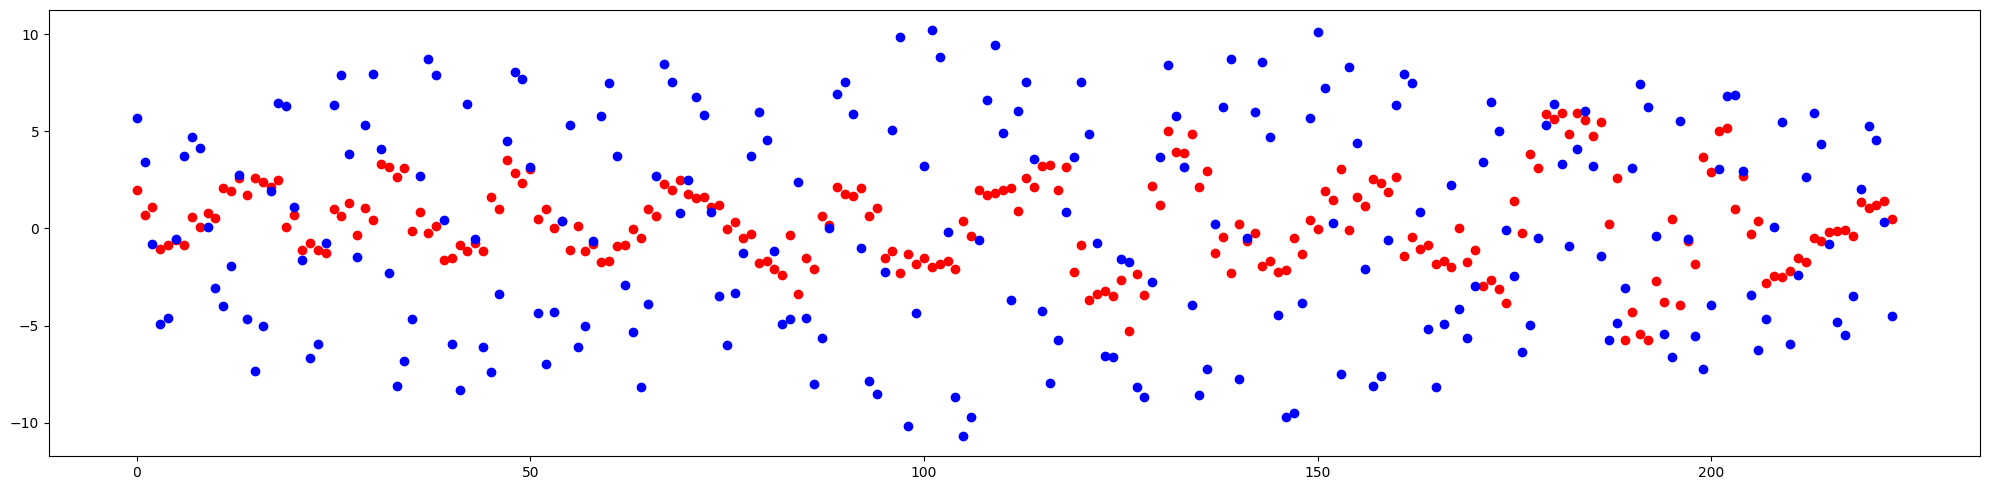

2.33
5.48


In [16]:
# Compare with model

_, bx, _, by = model.out_cs[model.monitor_index].T

plt.figure(figsize=(20, 5))
plt.scatter(range(model.monitor_count), 100*(((model.bx[model.monitor_index] - bx)/model.bx[model.monitor_index])).cpu().numpy(), color='red')
plt.scatter(range(model.monitor_count), 100*(((model.by[model.monitor_index] - by)/model.by[model.monitor_index])).cpu().numpy(), color='blue')
plt.tight_layout()
plt.show()

print(f'{100*root_mean_square((model.bx[model.monitor_index] - bx)/model.bx[model.monitor_index]).item():.2f}')
print(f'{100*root_mean_square((model.by[model.monitor_index] - by)/model.by[model.monitor_index]).item():.2f}')

In [17]:
# Set calibration errors
# Note, all scales have mean value not equal to one

g_xx = 0.0 + 2.5E-2*torch.randn(model.monitor_count, dtype=dtype, device=device)
g_xy = 0.0 + 5.0E-3*torch.randn(model.monitor_count, dtype=dtype, device=device)
g_yx = 0.0 + 5.0E-3*torch.randn(model.monitor_count, dtype=dtype, device=device)
g_yy = 0.0 + 2.5E-2*torch.randn(model.monitor_count, dtype=dtype, device=device)

# Set scales for two groups

g_xx[:model.monitor_count // 2] += 1.05
g_yy[:model.monitor_count // 2] += 0.95

g_xx[model.monitor_count // 2:] += 1.10
g_yy[model.monitor_count // 2:] += 0.90

In [18]:
# Compute calibration matrices ((gxx, gxy), (gyx, gyy)) for each bpm (qx, px, qy, py)

bpm = torch.vmap(calibration)(g_xx, g_xy, g_yx, g_yy)

In [19]:
# Compute transformed twiss parameters

normal = model.out_normal[model.monitor_index]

n11 = normal[:, 0, 0]
n12 = normal[:, 0, 1]
n13 = normal[:, 0, 2]
n14 = normal[:, 0, 3]

n21 = normal[:, 1, 0]
n22 = normal[:, 1, 1]
n23 = normal[:, 1, 2]
n24 = normal[:, 1, 3]

n31 = normal[:, 2, 0]
n32 = normal[:, 2, 1]
n33 = normal[:, 2, 2]
n34 = normal[:, 2, 3]

n41 = normal[:, 3, 0]
n42 = normal[:, 3, 1]
n43 = normal[:, 3, 2]
n44 = normal[:, 3, 3]

advance_bpm, normal_bpm = torch.vmap(advance)(normal, bpm)

mux_bpm, muy_bpm = mod(-advance_bpm  + torch.stack([mux, muy]).T + advance_bpm.roll(-1, 0), 2*numpy.pi).T

n11_bpm = normal_bpm[:, 0, 0]
n12_bpm = normal_bpm[:, 0, 1]
n13_bpm = normal_bpm[:, 0, 2]
n14_bpm = normal_bpm[:, 0, 3]

n21_bpm = normal_bpm[:, 1, 0]
n22_bpm = normal_bpm[:, 1, 1]
n23_bpm = normal_bpm[:, 1, 2]
n24_bpm = normal_bpm[:, 1, 3]

n31_bpm = normal_bpm[:, 2, 0]
n32_bpm = normal_bpm[:, 2, 1]
n33_bpm = normal_bpm[:, 2, 2]
n34_bpm = normal_bpm[:, 2, 3]

n41_bpm = normal_bpm[:, 3, 0]
n42_bpm = normal_bpm[:, 3, 1]
n43_bpm = normal_bpm[:, 3, 2]
n44_bpm = normal_bpm[:, 3, 3]

In [20]:
# Beta beating

_, bx_bpm, _, by_bpm = torch.stack([wolski_to_cs(matrix) for matrix in normal_to_wolski(normal_bpm)]).T

print(f'{100*root_mean_square((model.bx[model.monitor_index] - bx)/model.bx[model.monitor_index]).item():.2f}')
print(f'{100*root_mean_square((model.by[model.monitor_index] - by)/model.by[model.monitor_index]).item():.2f}')
print()

print(f'{100*root_mean_square((model.bx[model.monitor_index] - bx_bpm)/model.bx[model.monitor_index]).item():.2f}')
print(f'{100*root_mean_square((model.by[model.monitor_index] - by_bpm)/model.by[model.monitor_index]).item():.2f}')
print()

2.33
5.48

17.40
16.74



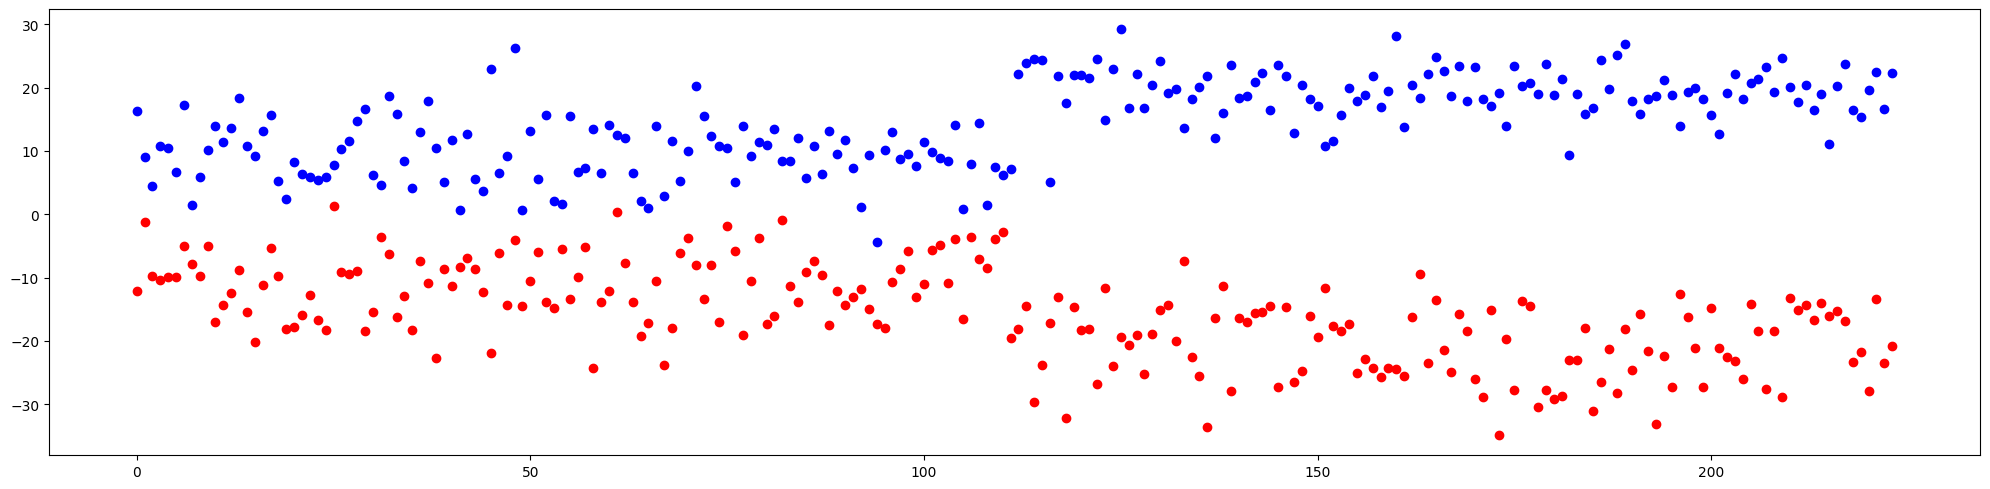

In [21]:
# Plot beta difference

plt.figure(figsize=(20, 5))
plt.scatter(range(model.monitor_count), 100*((bx - bx_bpm)/bx).cpu().numpy(), color='red')
plt.scatter(range(model.monitor_count), 100*((by - by_bpm)/by).cpu().numpy(), color='blue')
plt.tight_layout()
plt.show()

## Harmonic decomposition

In [22]:
# Generate TbT signals at monitors (beam frame)

point = torch.tensor([0.00075, 0.0, 0.000375, 0.0], dtype=dtype, device=device)
qx, px, qy, py =  model.make_trajectory(point, length, error=True, transport=True)[model.monitor_index].permute(-1, 0, 1)

print(qx.shape)
print(px.shape)
print(qy.shape)
print(py.shape)

torch.Size([224, 2048])
torch.Size([224, 2048])
torch.Size([224, 2048])
torch.Size([224, 2048])


In [23]:
# Generate TbT signals at monitors (bpm frame)

qx_bpm, px_bpm, qy_bpm, py_bpm = (bpm @ torch.stack([qx, px, qy, py]).permute(1, 0, -1)).permute(1, 0, -1)

print(qx_bpm.shape)
print(px_bpm.shape)
print(qy_bpm.shape)
print(py_bpm.shape)

torch.Size([224, 2048])
torch.Size([224, 2048])
torch.Size([224, 2048])
torch.Size([224, 2048])


In [24]:
# Compare invariants

ix, iy = torch.vmap(invariant)(normal, torch.stack([qx, px, qy, py]).permute(1, -1, 0)).swapaxes(0, 1).mean(-1)
ix_bpm, iy_bpm = torch.vmap(invariant)(normal_bpm, torch.stack([qx_bpm, px_bpm, qy_bpm, py_bpm]).permute(1, -1, 0)).swapaxes(0, 1).mean(-1)

print(torch.allclose(ix, ix_bpm))
print(torch.allclose(iy, iy_bpm))

True
True


In [25]:
# Perform harmonic decmposition of TbT data without calibration errors

In [26]:
# Set data containers

tbt_x.data = qx.clone()
tbt_x.work = qx.clone()
tbt_x.reset()

tbt_y.data = qy.clone()
tbt_y.work = qy.clone()
tbt_y.reset()

In [27]:
# Compute frequencies (horizontal and vertical)

tbt_x.window_remove_mean()
tbt_x.window_apply()
f_x('parabola')
tbt_x.reset()

tbt_y.window_remove_mean()
tbt_y.window_apply()
f_y('parabola')
tbt_y.reset()

nux, sigma_nux = 1.0 - f_x.frequency.mean(),  f_x.frequency.std()
nuy, sigma_nuy = 1.0 - f_y.frequency.mean(),  f_y.frequency.std()

In [28]:
# Compute amplitudes and phases (horizontal and vertical)

axx, _, _ = d_x.harmonic_amplitude(nux, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
fxx, _, _ = d_x.harmonic_phase(nux, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
axy, _, _ = d_x.harmonic_amplitude(nuy, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
fxy, _, _ = d_x.harmonic_phase(nuy, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
ayy, _, _ = d_y.harmonic_amplitude(nuy, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
fyy, _, _ = d_y.harmonic_phase(nuy, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
ayx, _, _ = d_y.harmonic_amplitude(nux, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
fyx, _, _ = d_y.harmonic_phase(nux, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)

In [29]:
# Check reconstruction

# qx(n) = axx cos(2 pi nux n + fxx) + axy cos(2 pi nuy n + fxy)
# qy(n) = ayy cos(2 pi nuy n + fyy) + ayx cos(2 pi nux n + fyx)

t = torch.linspace(0, length - 1, length, dtype=dtype, device=device)

print(torch.allclose(qx, axx.reshape(-1, 1)*(2*torch.pi*nux*t + fxx.reshape(-1, 1)).cos() + axy.reshape(-1, 1)*(2*torch.pi*nuy*t + fxy.reshape(-1, 1)).cos()))
print(torch.allclose(qy, ayy.reshape(-1, 1)*(2*torch.pi*nuy*t + fyy.reshape(-1, 1)).cos() + ayx.reshape(-1, 1)*(2*torch.pi*nux*t + fyx.reshape(-1, 1)).cos()))

True
True


In [30]:
# Set table

table = Table(model.monitor_name,
              nux, nuy,
              axx, ayy, fxx, fyy,
              x=qx,
              y=qy,
              dtype=dtype,
              device=device)

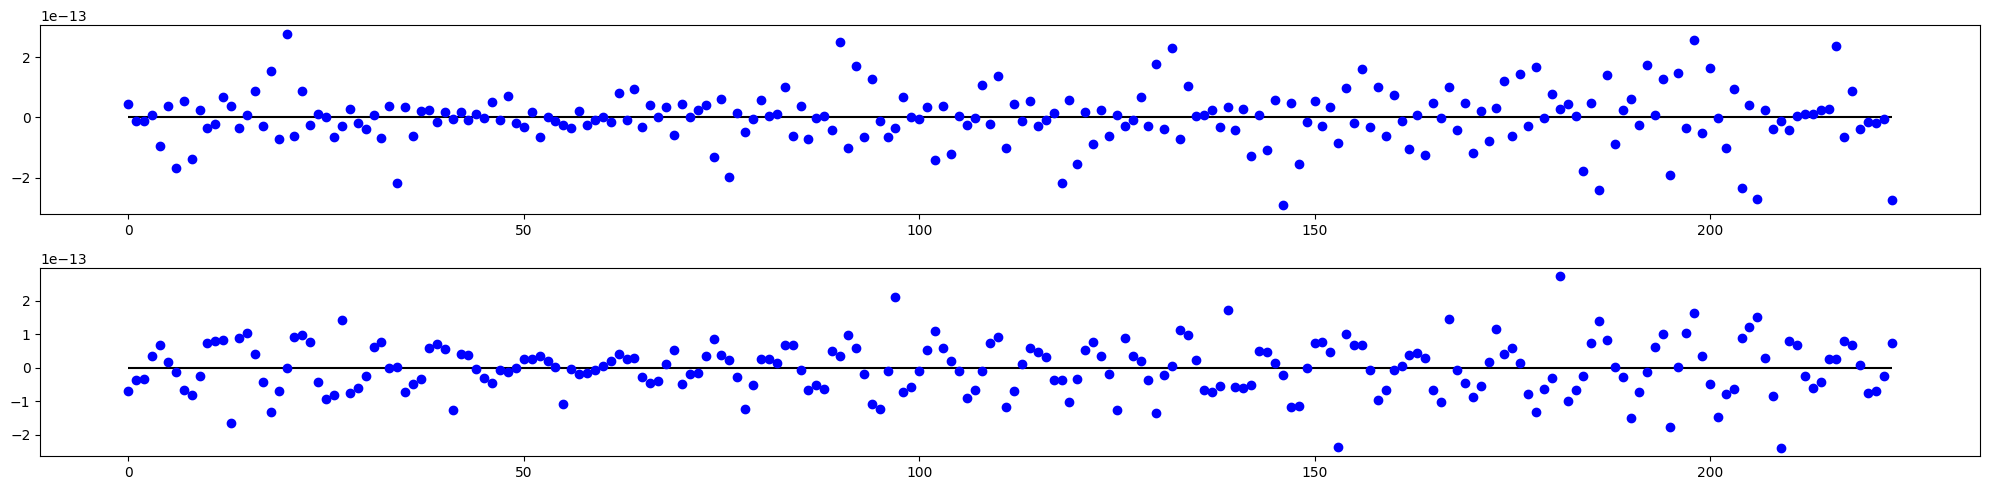

In [31]:
# Compare phase advance

plt.figure(figsize=(20, 5))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), (mux - table.phase_x.cpu().numpy()), fmt=' ', marker='o', color='blue')
ax.hlines(0, 0, model.monitor_count - 1, colors='black')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), (muy - table.phase_y.cpu().numpy()), fmt=' ', marker='o', color='blue')
ax.hlines(0, 0, model.monitor_count - 1, colors='black')
plt.tight_layout()
plt.show()

In [32]:
# Perform harmonic decmposition of TbT data wit calibration errors

In [33]:
# Set data containers

tbt_x.data = qx_bpm.clone()
tbt_x.work = qx_bpm.clone()
tbt_x.reset()

tbt_y.data = qy_bpm.clone()
tbt_y.work = qy_bpm.clone()
tbt_y.reset()

In [34]:
# Compute frequencies (horizontal and vertical)

tbt_x.window_remove_mean()
tbt_x.window_apply()
f_x('parabola')
tbt_x.reset()

tbt_y.window_remove_mean()
tbt_y.window_apply()
f_y('parabola')
tbt_y.reset()

nux_bpm, sigma_nux = 1.0 - f_x.frequency.mean(),  f_x.frequency.std()
nuy_bpm, sigma_nuy = 1.0 - f_y.frequency.mean(),  f_y.frequency.std()

print(torch.allclose(nux, nux_bpm))
print(torch.allclose(nuy, nuy_bpm))

True
True


In [35]:
# Compute amplitudes and phases (horizontal and vertical)

axx_bpm, sigma_ax, _ = d_x.harmonic_amplitude(nux_bpm, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
fxx_bpm, sigma_fx, _ = d_x.harmonic_phase(nux_bpm, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
axy_bpm, _, _ = d_x.harmonic_amplitude(nuy_bpm, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
fxy_bpm, _, _ = d_x.harmonic_phase(nuy_bpm, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
ayy_bpm, sigma_ay, _ = d_y.harmonic_amplitude(nuy_bpm, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
fyy_bpm, sigma_fy, _ = d_y.harmonic_phase(nuy_bpm, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
ayx_bpm, _, _ = d_y.harmonic_amplitude(nux_bpm, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
fyx_bpm, _, _ = d_y.harmonic_phase(nux_bpm, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)

In [36]:
# Check reconstruction

# qx(n) = axx cos(2 pi nux n + fxx) + axy cos(2 pi nuy n + fxy)
# qy(n) = ayy cos(2 pi nuy n + fyy) + ayx cos(2 pi nux n + fyx)

t = torch.linspace(0, length - 1, length, dtype=dtype, device=device)

print(torch.allclose(qx_bpm, axx_bpm.reshape(-1, 1)*(2*torch.pi*nux_bpm*t + fxx_bpm.reshape(-1, 1)).cos() + axy_bpm.reshape(-1, 1)*(2*torch.pi*nuy_bpm*t + fxy_bpm.reshape(-1, 1)).cos()))
print(torch.allclose(qy_bpm, ayy_bpm.reshape(-1, 1)*(2*torch.pi*nuy_bpm*t + fyy_bpm.reshape(-1, 1)).cos() + ayx_bpm.reshape(-1, 1)*(2*torch.pi*nux_bpm*t + fyx_bpm.reshape(-1, 1)).cos()))

True
True


In [37]:
# Set table

table_bpm = Table(model.monitor_name,
                  nux_bpm, nuy_bpm,
                  axx_bpm, ayy_bpm, fxx_bpm, fyy_bpm, 
                  sigma_nux, sigma_nuy,
                  sigma_ax, sigma_ay,
                  sigma_fx, sigma_fy,
                  x=qx_bpm,
                  y=qy_bpm,
                  dtype=dtype,
                  device=device)

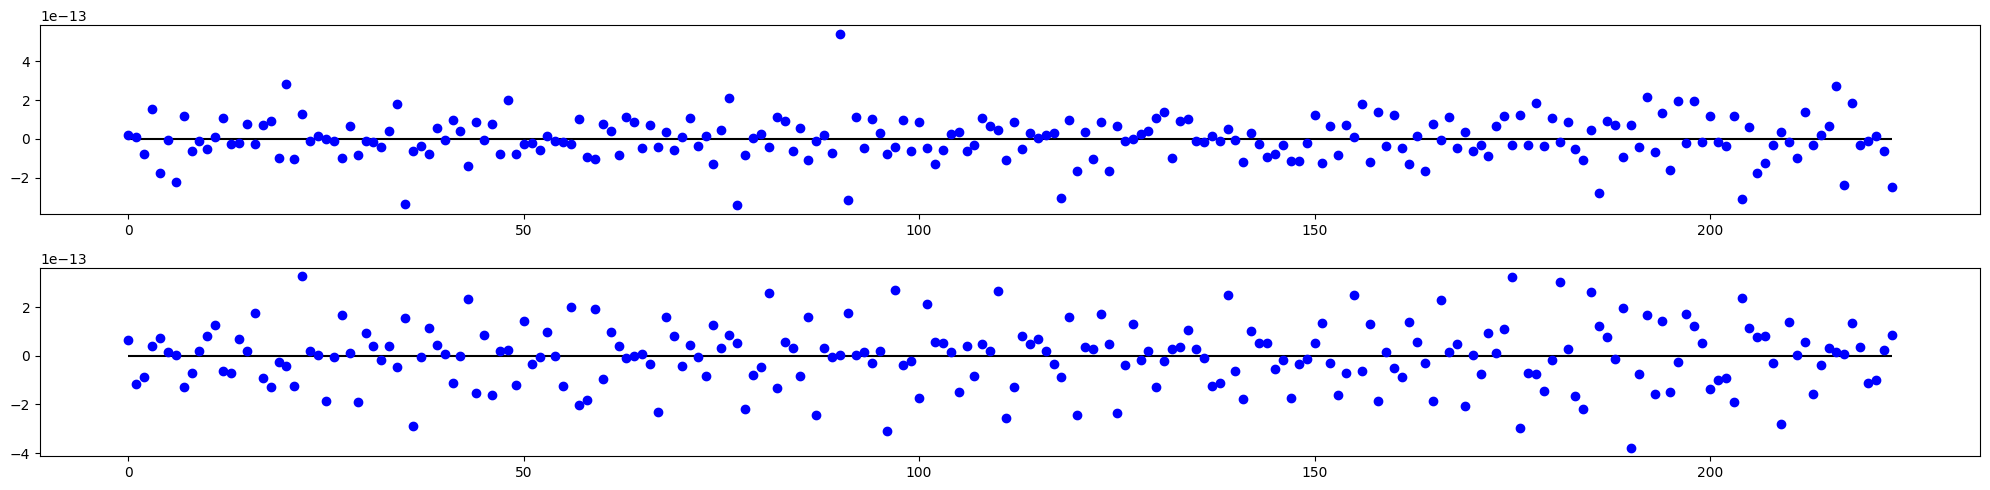

In [38]:
# Compare phase advance

plt.figure(figsize=(20, 5))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), (mux_bpm - table_bpm.phase_x.cpu().numpy()), fmt=' ', marker='o', color='blue')
ax.hlines(0, 0, model.monitor_count - 1, colors='black')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), (muy_bpm - table_bpm.phase_y.cpu().numpy()), fmt=' ', marker='o', color='blue')
ax.hlines(0, 0, model.monitor_count - 1, colors='black')
plt.tight_layout()
plt.show()

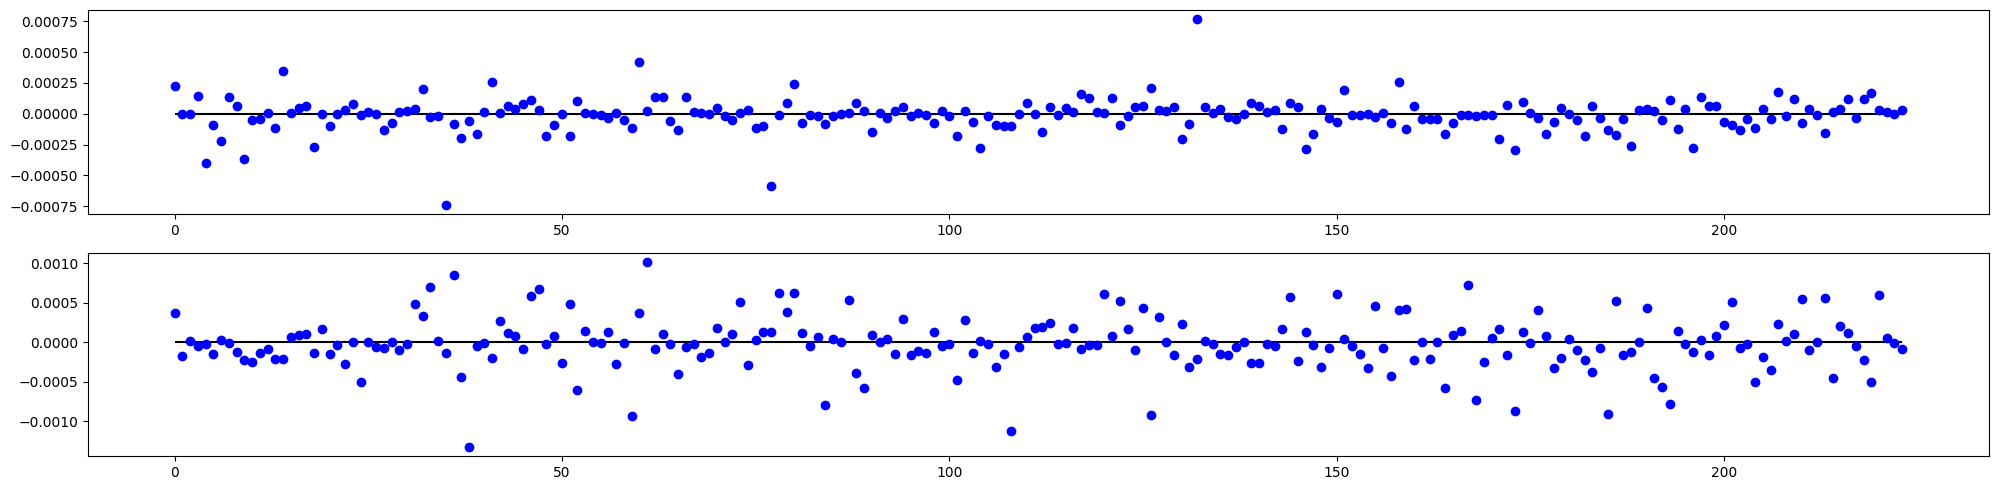

In [39]:
# Compare phases without calibration errors vs with calibration errors
# Note, without bpm rolls, phases are equal

plt.figure(figsize=(20, 5))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), (fxx - fxx_bpm).cpu().numpy(), fmt=' ', marker='o', color='blue')
ax.hlines(0, 0, model.monitor_count - 1, colors='black')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), (fyy - fyy_bpm).cpu().numpy(), fmt=' ', marker='o', color='blue')
ax.hlines(0, 0, model.monitor_count - 1, colors='black')
plt.tight_layout()
plt.show()

## Twiss from amplitude & phase

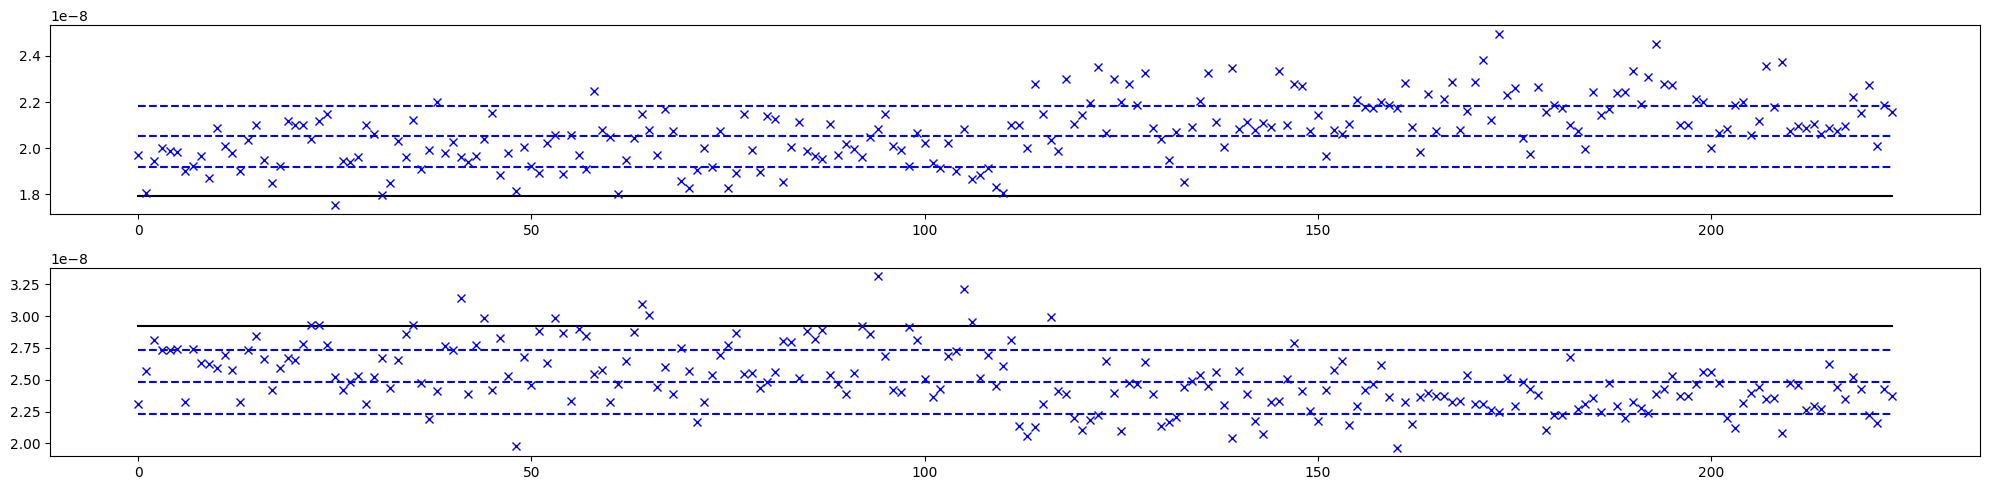

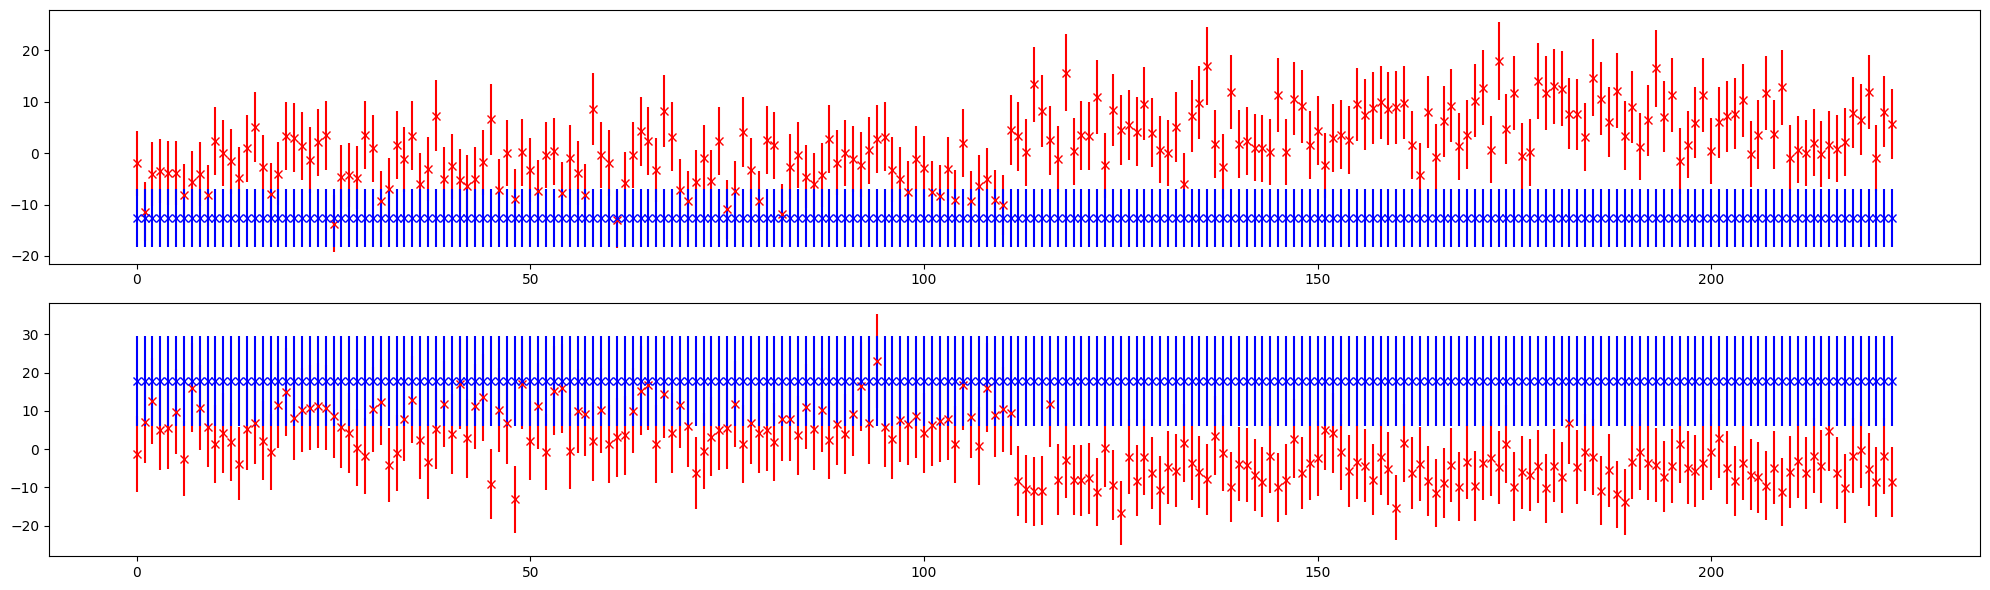

tensor(6.6419, dtype=torch.float64)
tensor(7.9426, dtype=torch.float64)

tensor(12.5467, dtype=torch.float64)
tensor(17.7400, dtype=torch.float64)



In [40]:
# Estimate twiss from amplitude

twiss = Twiss(model, table_bpm, limit=1)
twiss.get_action()
twiss.get_twiss_from_amplitude()

# Compare estimated invariants

plt.figure(figsize=(20, 5))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), ix.cpu().numpy(), fmt='-', color='black')
ax.errorbar(range(model.monitor_count), twiss.action['jx'].cpu().numpy(), yerr=twiss.action['sigma_jx'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax.hlines([(twiss.action['center_jx'] - twiss.action['spread_jx']).cpu().numpy(), twiss.action['center_jx'].cpu().numpy(), (twiss.action['center_jx'] + twiss.action['spread_jx']).cpu().numpy()], 0, model.monitor_count - 1, color='blue', linestyle='dashed')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), iy.cpu().numpy(), fmt='-', color='black')
ax.errorbar(range(model.monitor_count), twiss.action['jy'].cpu().numpy(), yerr=twiss.action['sigma_jy'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax.hlines([(twiss.action['center_jy'] - twiss.action['spread_jy']).cpu().numpy(), twiss.action['center_jy'].cpu().numpy(), (twiss.action['center_jy'] + twiss.action['spread_jy']).cpu().numpy()], 0, model.monitor_count - 1, color='blue', linestyle='dashed')
plt.tight_layout()
plt.show()

# Compare estimated twiss
# Note, large error bars are due to invariant estimation spread

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['bx'] - bx)/bx).cpu().numpy(), yerr=100/bx*twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['bx'] - bx_bpm)/bx_bpm).cpu().numpy(), yerr=100/bx_bpm*twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['by'] - by)/by).cpu().numpy(), yerr=100/by*twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['by'] - by_bpm)/by_bpm).cpu().numpy(), yerr=100/by_bpm*twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()

# Note, using amplitude, twiss in bpm frame is estimated, but crude estimation of invariants lead to systematic shift

print(root_mean_square(100*((twiss.data_amplitude['bx'] - bx)/bx)))
print(root_mean_square(100*((twiss.data_amplitude['by'] - by)/by)))
print()

print(root_mean_square(100*((twiss.data_amplitude['bx'] - bx_bpm)/bx_bpm)))
print(root_mean_square(100*((twiss.data_amplitude['by'] - by_bpm)/by_bpm)))
print()

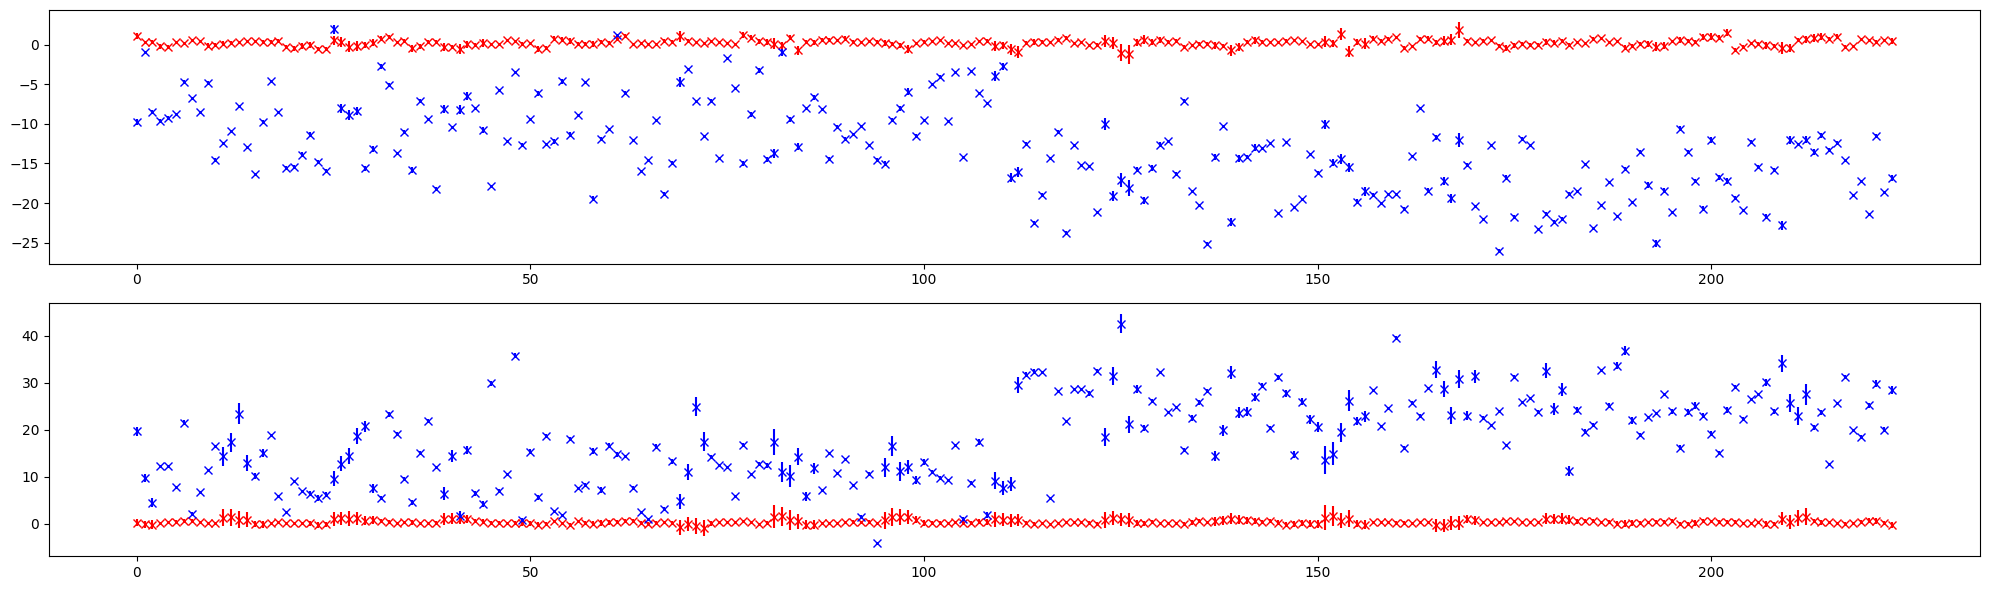

tensor(0.5119, dtype=torch.float64)
tensor(0.5837, dtype=torch.float64)

tensor(14.3156, dtype=torch.float64)
tensor(20.2609, dtype=torch.float64)



In [41]:
# Estimate twiss from phase

twiss = Twiss(model, table_bpm, limit=4)
twiss.phase_virtual()
twiss.get_twiss_from_phase()
mask_x = twiss.filter_twiss(plane='x', phase={'use': True, 'threshold': 10.0}, model={'use': False, 'threshold': 0.5}, value={'use': False, 'threshold': 0.5}, sigma={'use': False, 'threshold': 0.25}, limit={'use': True, 'threshold': 5.0})
mask_y = twiss.filter_twiss(plane='y', phase={'use': True, 'threshold': 10.0}, model={'use': False, 'threshold': 0.5}, value={'use': False, 'threshold': 0.5}, sigma={'use': False, 'threshold': 0.25}, limit={'use': True, 'threshold': 5.0})
_ = twiss.process_twiss(plane='x', mask=mask_x, weight=True)
_ = twiss.process_twiss(plane='y', mask=mask_y, weight=True)

# Note, (uncoupled) invariants can be computed for given coordinates and momenta

# Compare estimated twiss

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((twiss.bx[model.monitor_index] - bx)/bx).cpu().numpy(), yerr=100/bx*twiss.sigma_bx[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((twiss.bx[model.monitor_index] - bx_bpm)/bx_bpm).cpu().numpy(), yerr=100/bx_bpm*twiss.sigma_bx[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((twiss.by[model.monitor_index] - by)/by).cpu().numpy(), yerr=100/by*twiss.sigma_by[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((twiss.by[model.monitor_index] - by_bpm)/by_bpm).cpu().numpy(), yerr=100/by_bpm*twiss.sigma_by[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()

print(root_mean_square(100*((twiss.bx[model.monitor_index] - bx)/bx)))
print(root_mean_square(100*((twiss.by[model.monitor_index] - by)/by)))
print()

print(root_mean_square(100*((twiss.bx[model.monitor_index] - bx_bpm)/bx_bpm)))
print(root_mean_square(100*((twiss.by[model.monitor_index] - by_bpm)/by_bpm)))
print()

# Note, estimated twiss parameters are closer to beam frame ones

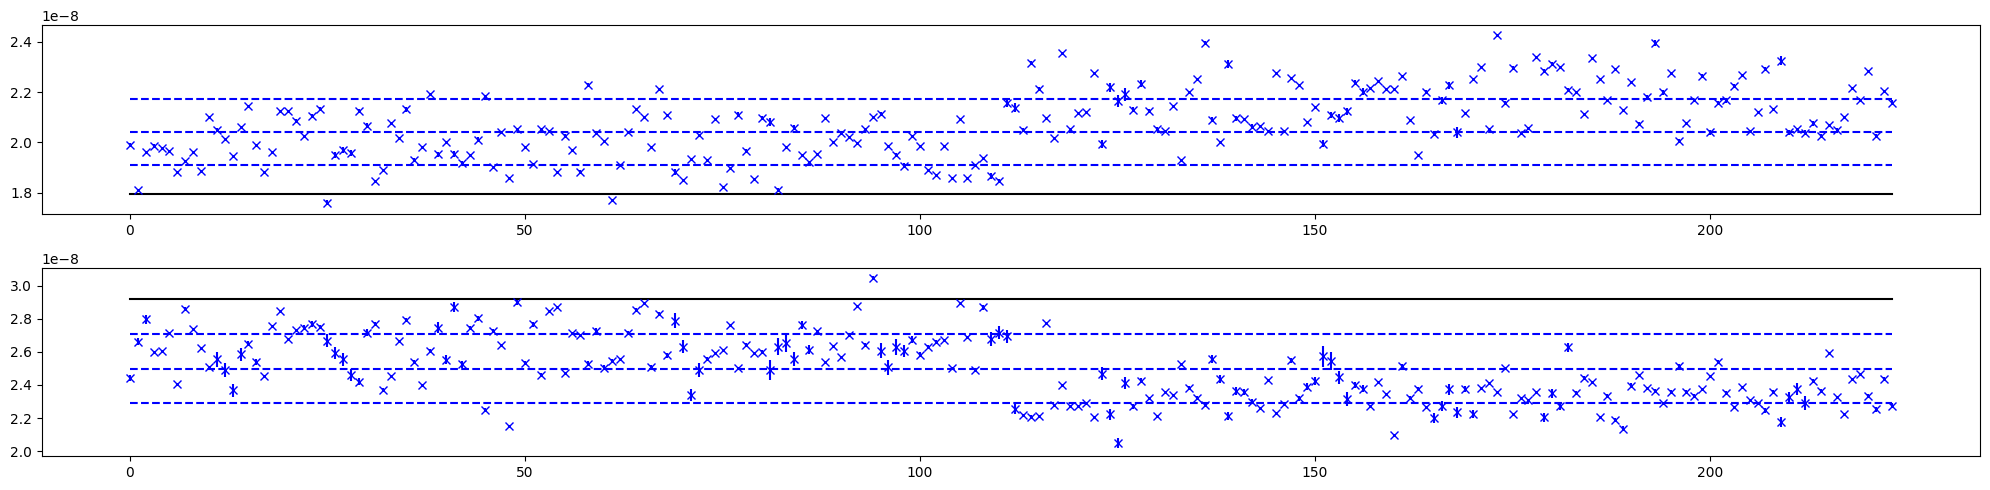

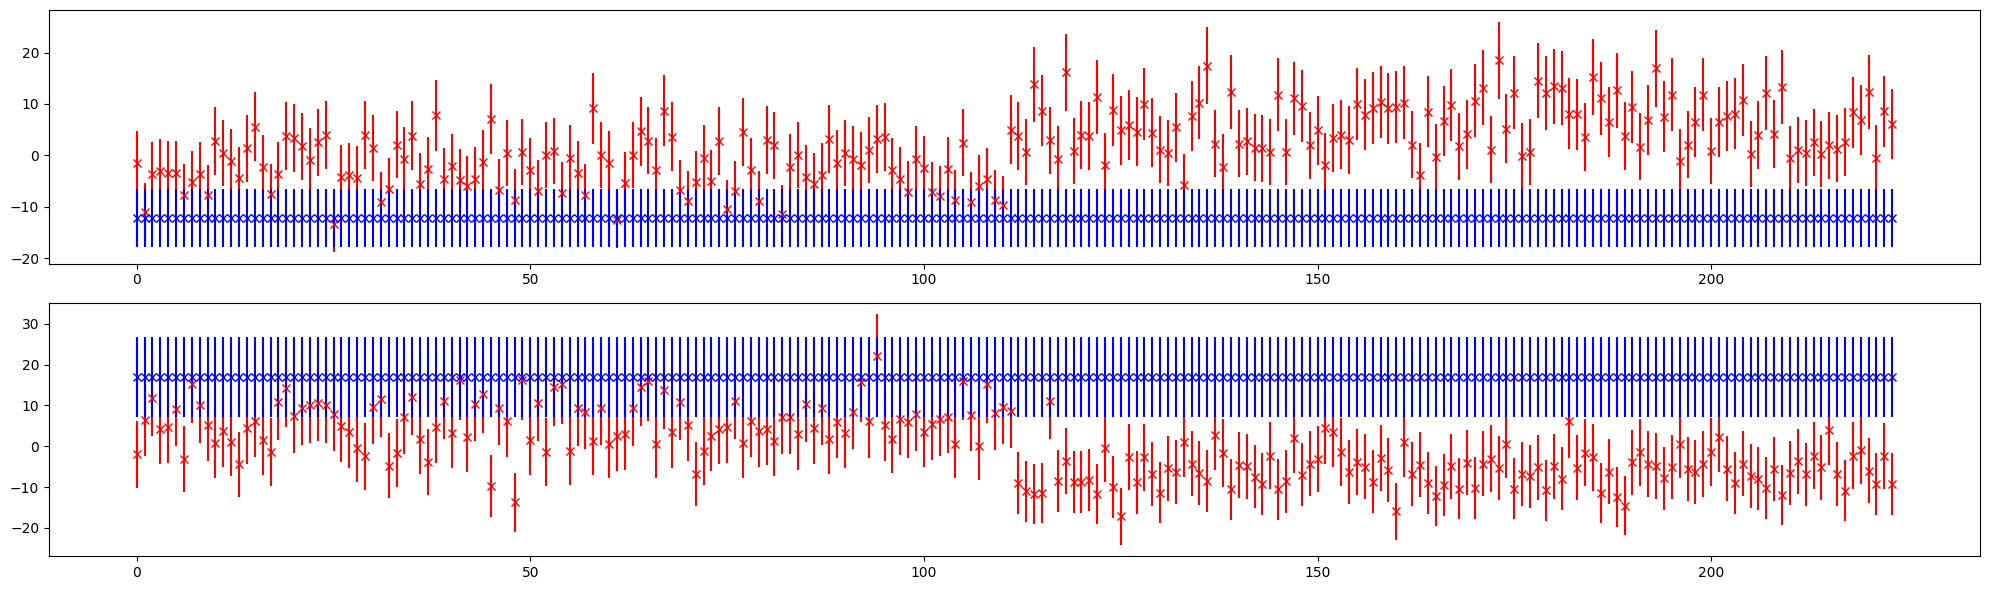

tensor(6.7784, dtype=torch.float64)
tensor(7.8582, dtype=torch.float64)

tensor(12.1596, dtype=torch.float64)
tensor(16.9869, dtype=torch.float64)



In [42]:
# Estimate twiss from amplitude (use twiss from phase for action estimation)

twiss.get_action(bx=twiss.bx[model.monitor_index], by=twiss.by[model.monitor_index], sigma_bx=twiss.sigma_bx[model.monitor_index], sigma_by=twiss.sigma_by[model.monitor_index])
twiss.get_twiss_from_amplitude()

# Compare estimated invariants

plt.figure(figsize=(20, 5))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), ix.cpu().numpy(), fmt='-', color='black')
ax.errorbar(range(model.monitor_count), twiss.action['jx'].cpu().numpy(), yerr=twiss.action['sigma_jx'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax.hlines([(twiss.action['center_jx'] - twiss.action['spread_jx']).cpu().numpy(), twiss.action['center_jx'].cpu().numpy(), (twiss.action['center_jx'] + twiss.action['spread_jx']).cpu().numpy()], 0, model.monitor_count - 1, color='blue', linestyle='dashed')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), iy.cpu().numpy(), fmt='-', color='black')
ax.errorbar(range(model.monitor_count), twiss.action['jy'].cpu().numpy(), yerr=twiss.action['sigma_jy'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax.hlines([(twiss.action['center_jy'] - twiss.action['spread_jy']).cpu().numpy(), twiss.action['center_jy'].cpu().numpy(), (twiss.action['center_jy'] + twiss.action['spread_jy']).cpu().numpy()], 0, model.monitor_count - 1, color='blue', linestyle='dashed')
plt.tight_layout()
plt.show()

# Compare estimated twiss

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['bx'] - bx)/bx).cpu().numpy(), yerr=100/bx*twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['bx'] - bx_bpm)/bx_bpm).cpu().numpy(), yerr=100/bx_bpm*twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['by'] - by)/by).cpu().numpy(), yerr=100/by*twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['by'] - by_bpm)/by_bpm).cpu().numpy(), yerr=100/by_bpm*twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()

print(root_mean_square(100*((twiss.data_amplitude['bx'] - bx)/bx)))
print(root_mean_square(100*((twiss.data_amplitude['by'] - by)/by)))
print()

print(root_mean_square(100*((twiss.data_amplitude['bx'] - bx_bpm)/bx_bpm)))
print(root_mean_square(100*((twiss.data_amplitude['by'] - by_bpm)/by_bpm)))
print()

## Twiss from invariant fit

In [43]:
%%time

# Estimate twiss from invariant fit

count = 8

data = twiss.get_twiss_from_data(1,                # -- first turn
                                 256,              # -- total number of turns, orbits are computed for (start, start + total)
                                 parametric_normal,# -- normalization
                                 model.matrix,     # -- transport matrix generator
                                 twiss=None,       # -- initial twiss for each location or None (use model values)
                                 method='lstsq',   # -- momenta computation method
                                 limit=2,          # -- range limit or direction/shift
                                 product=True,     # -- flag to use product objective
                                 jacobian=False,   # -- flag to use objective jacobian
                                 count=count,      # -- number of samples
                                 fraction=0.75,    # -- sample length fraction
                                 ix=None,          # -- ix invariant value
                                 iy=None,          # -- iy invariant value  (both should present for fixed fit)
                                 n_jobs=4,         # -- number of parallel jobs (loop over samples)
                                 verbose=False)    # -- verbose flag

CPU times: user 8min 18s, sys: 1min 41s, total: 10min
Wall time: 12min 9s


In [44]:
# Process fitted invariants

ix_out = data[:, 0, 0]
iy_out = data[:, 0, 1]

sigma_ix = data[:, 1, 0]
sigma_iy = data[:, 1, 1]

invariant = twiss.get_invariant(ix_out, iy_out, sigma_ix, sigma_iy)

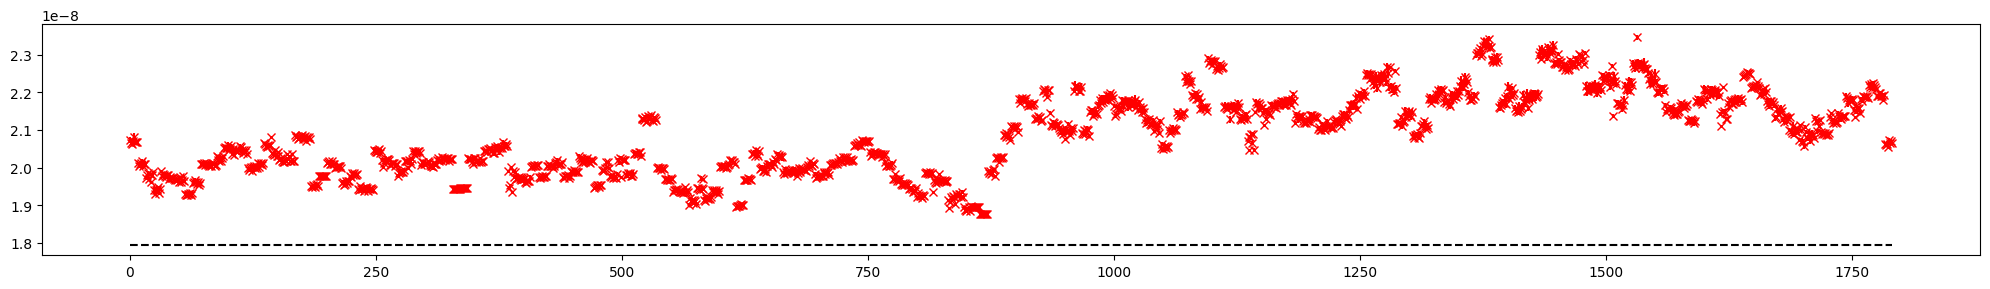

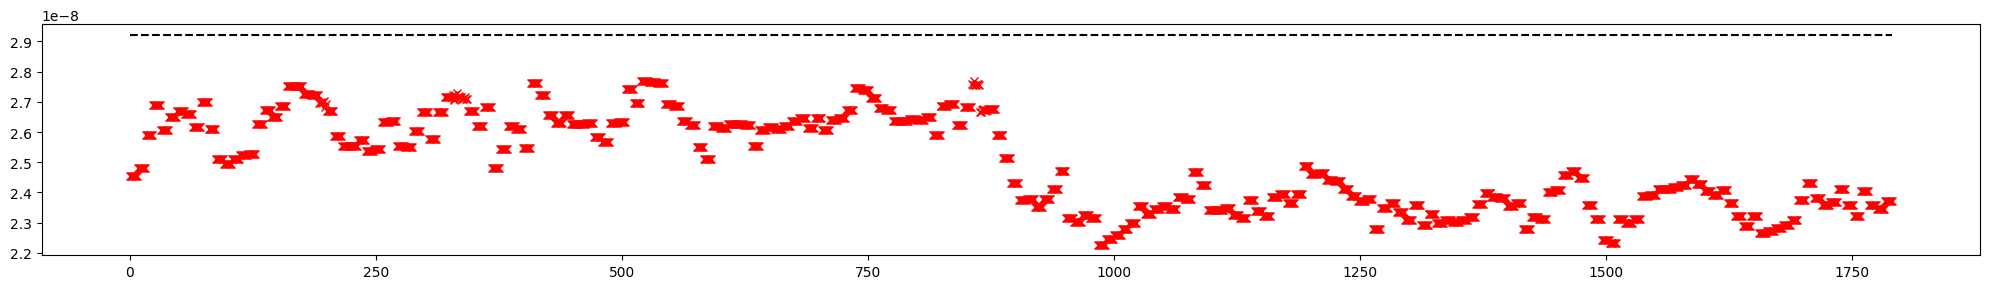

In [45]:
# Plot invariants for each sample in each signal

plt.figure(figsize=(20, 3))
plt.errorbar(range(count*model.monitor_count), ix_out.flatten().cpu().numpy(), yerr=sigma_ix.flatten().cpu().numpy(), fmt=' ', color='red', marker='x', zorder=0)
plt.hlines(ix.mean(), 0, count*model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 3))
plt.errorbar(range(count*model.monitor_count), iy_out.flatten().cpu().numpy(), yerr=sigma_iy.flatten().cpu().numpy(), fmt=' ', color='red', marker='x', zorder=0)
plt.hlines(iy.mean(), 0, count*model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.tight_layout()
plt.show()

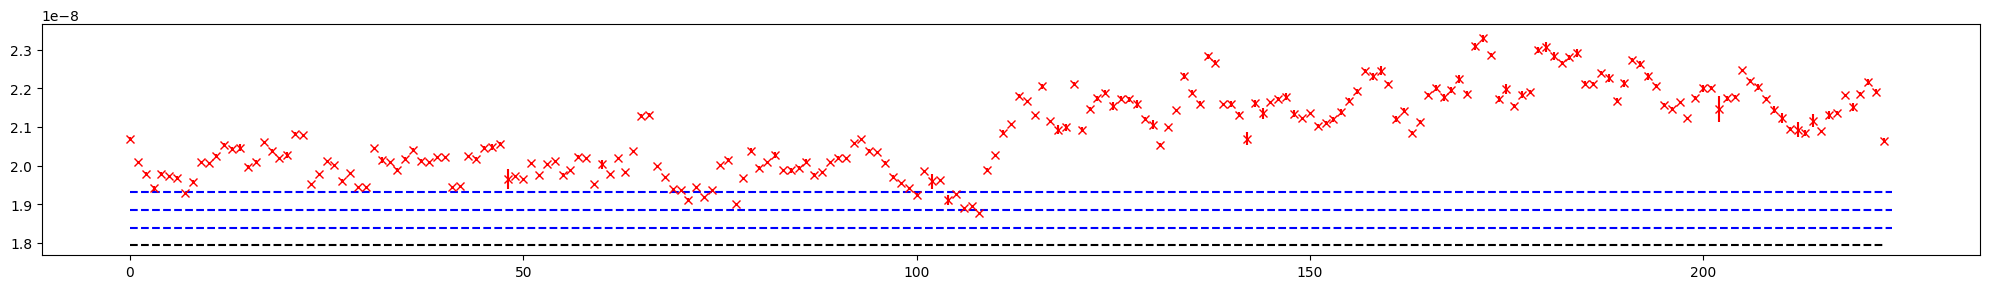

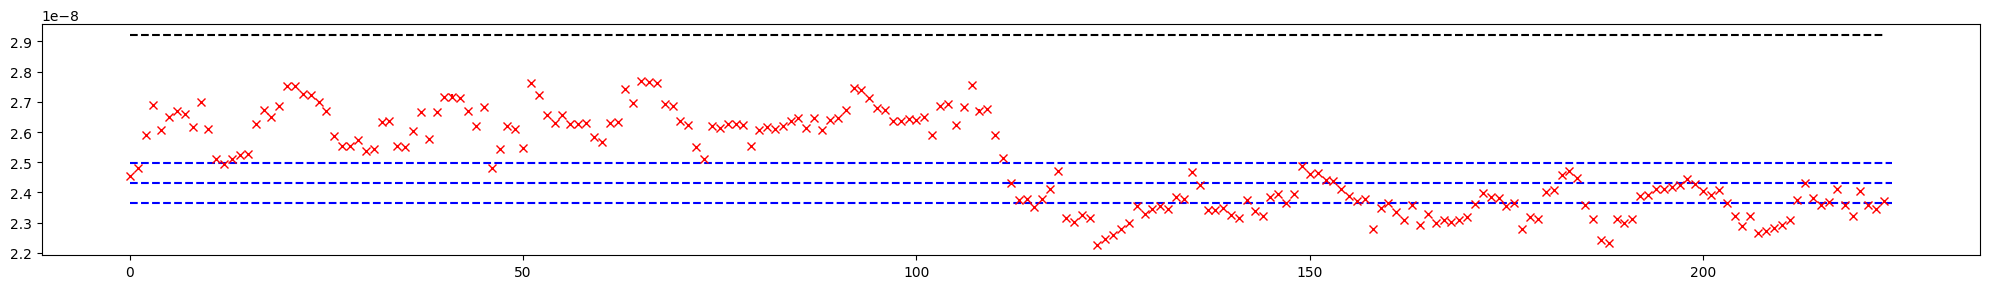

tensor(1.7944e-08, dtype=torch.float64)
tensor(2.0428e-08, dtype=torch.float64)
tensor(1.8848e-08, dtype=torch.float64)
tensor(2.0854e-08, dtype=torch.float64)

tensor(2.9226e-08, dtype=torch.float64)
tensor(2.4982e-08, dtype=torch.float64)
tensor(2.4306e-08, dtype=torch.float64)
tensor(2.4962e-08, dtype=torch.float64)



In [46]:
# Plot invariants for each monitor

plt.figure(figsize=(20, 3))
plt.errorbar(range(model.monitor_count), invariant['ix_center'].flatten().cpu().numpy(), yerr=invariant['ix_spread'].flatten().cpu().numpy(), fmt=' ', color='red', marker='x')
plt.hlines(ix.mean(), 0, model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.hlines([invariant['ix_value'] - invariant['ix_error'], invariant['ix_value'], invariant['ix_value'] + invariant['ix_error']], 0, model.monitor_count, linestyles='dashed', color='blue')
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 3))
plt.errorbar(range(model.monitor_count), invariant['iy_center'].flatten().cpu().numpy(), yerr=invariant['iy_spread'].flatten().cpu().numpy(), fmt=' ', color='red', marker='x')
plt.hlines(iy.mean(), 0, model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.hlines([invariant['iy_value'] - invariant['iy_error'], invariant['iy_value'], invariant['iy_value'] + invariant['iy_error']], 0, model.monitor_count, linestyles='dashed', color='blue')
plt.tight_layout()
plt.show()

print(ix.mean())
print(twiss.action['center_jx'])
print(invariant['ix_value'])
print(ix_out.mean())
print()

print(iy.mean())
print(twiss.action['center_jy'])
print(invariant['iy_value'])
print(iy_out.mean())
print()

In [47]:
# Process twiss

value_n11 = data[:, 0, 2]
error_n11 = data[:, 1, 2]

value_n33 = data[:, 0, 3]
error_n33 = data[:, 1, 3]

value_n21 = data[:, 0, 4]
error_n21 = data[:, 1, 4]

value_n43 = data[:, 0, 5]
error_n43 = data[:, 1, 5]

value_n13 = data[:, 0, 6]
error_n13 = data[:, 1, 6]

value_n31 = data[:, 0, 7]
error_n31 = data[:, 1, 7]

value_n14 = data[:, 0, 8]
error_n14 = data[:, 1, 8]

value_n41 = data[:, 0, 9]
error_n41 = data[:, 1, 9]

value_n11, error_n11 = twiss.process(value_n11, error_n11)
value_n33, error_n33 = twiss.process(value_n33, error_n33)
value_n21, error_n21 = twiss.process(value_n21, error_n21)
value_n43, error_n43 = twiss.process(value_n43, error_n43)
value_n13, error_n13 = twiss.process(value_n13, error_n13)
value_n31, error_n31 = twiss.process(value_n31, error_n31)
value_n14, error_n14 = twiss.process(value_n14, error_n14)
value_n41, error_n41 = twiss.process(value_n41, error_n41)

value = torch.stack([value_n11, value_n33, value_n21, value_n43, value_n13, value_n31, value_n14, value_n41]).T
error = torch.stack([error_n11, error_n33, error_n21, error_n43, error_n13, error_n31, error_n14, error_n41]).T

cs_value, cs_error = [], []

for value_loc, error_loc in zip(value, error):
    table = value_loc.reshape(-1, 1) + error_loc.reshape(-1, 1)*torch.randn(1024, dtype=dtype, device=device)
    table = torch.stack([parametric_normal(*free) for free in table.T])
    table = normal_to_wolski(table)
    table = torch.stack([wolski_to_cs(w) for w in table]).T
    cs_value.append(table.mean(-1))
    cs_error.append(table.std(-1))
    
cs_value = torch.stack(cs_value)
cs_error = torch.stack(cs_error)

value_ax, value_bx, value_ay, value_by = cs_value.T
error_ax, error_bx, error_ay, error_by = cs_error.T

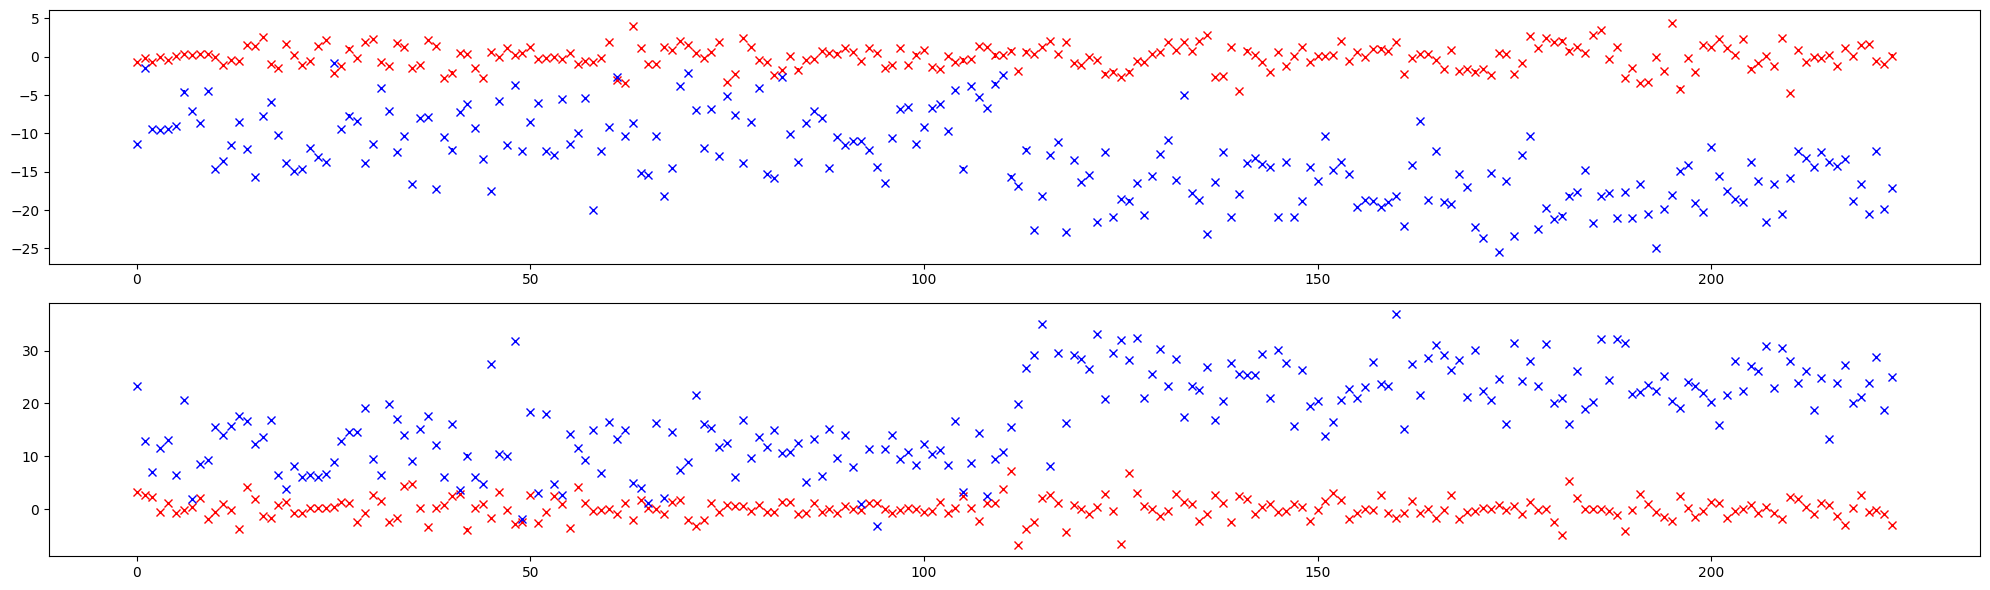

tensor(1.5405, dtype=torch.float64)
tensor(1.9645, dtype=torch.float64)

tensor(14.4523, dtype=torch.float64)
tensor(19.6520, dtype=torch.float64)



In [48]:
# Compare beta function values

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((value_bx - bx)/bx).cpu().numpy(), yerr=100/bx*error_bx.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((value_bx - bx_bpm)/bx_bpm).cpu().numpy(), yerr=100/bx_bpm*error_bx.cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((value_by - by)/by).cpu().numpy(), yerr=100/by*error_by.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((value_by - by_bpm)/by_bpm).cpu().numpy(), yerr=100/by_bpm*error_by.cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()

print(root_mean_square(100*((value_bx - bx)/bx)))
print(root_mean_square(100*((value_by - by)/by)))
print()

print(root_mean_square(100*((value_bx - bx_bpm)/bx_bpm)))
print(root_mean_square(100*((value_by - by_bpm)/by_bpm)))
print()

In [49]:
# Compare estimated normalization matrix elements

tensor(0.0238, dtype=torch.float64)
tensor(0.2507, dtype=torch.float64)

tensor(0.0217, dtype=torch.float64)
tensor(0.1626, dtype=torch.float64)

tensor(0.0134, dtype=torch.float64)
tensor(0.1207, dtype=torch.float64)

tensor(0.0164, dtype=torch.float64)
tensor(0.0884, dtype=torch.float64)

tensor(0.0190, dtype=torch.float64)
tensor(0.0299, dtype=torch.float64)

tensor(0.0147, dtype=torch.float64)
tensor(0.0138, dtype=torch.float64)

tensor(0.0182, dtype=torch.float64)
tensor(0.0274, dtype=torch.float64)

tensor(0.0084, dtype=torch.float64)
tensor(0.0148, dtype=torch.float64)



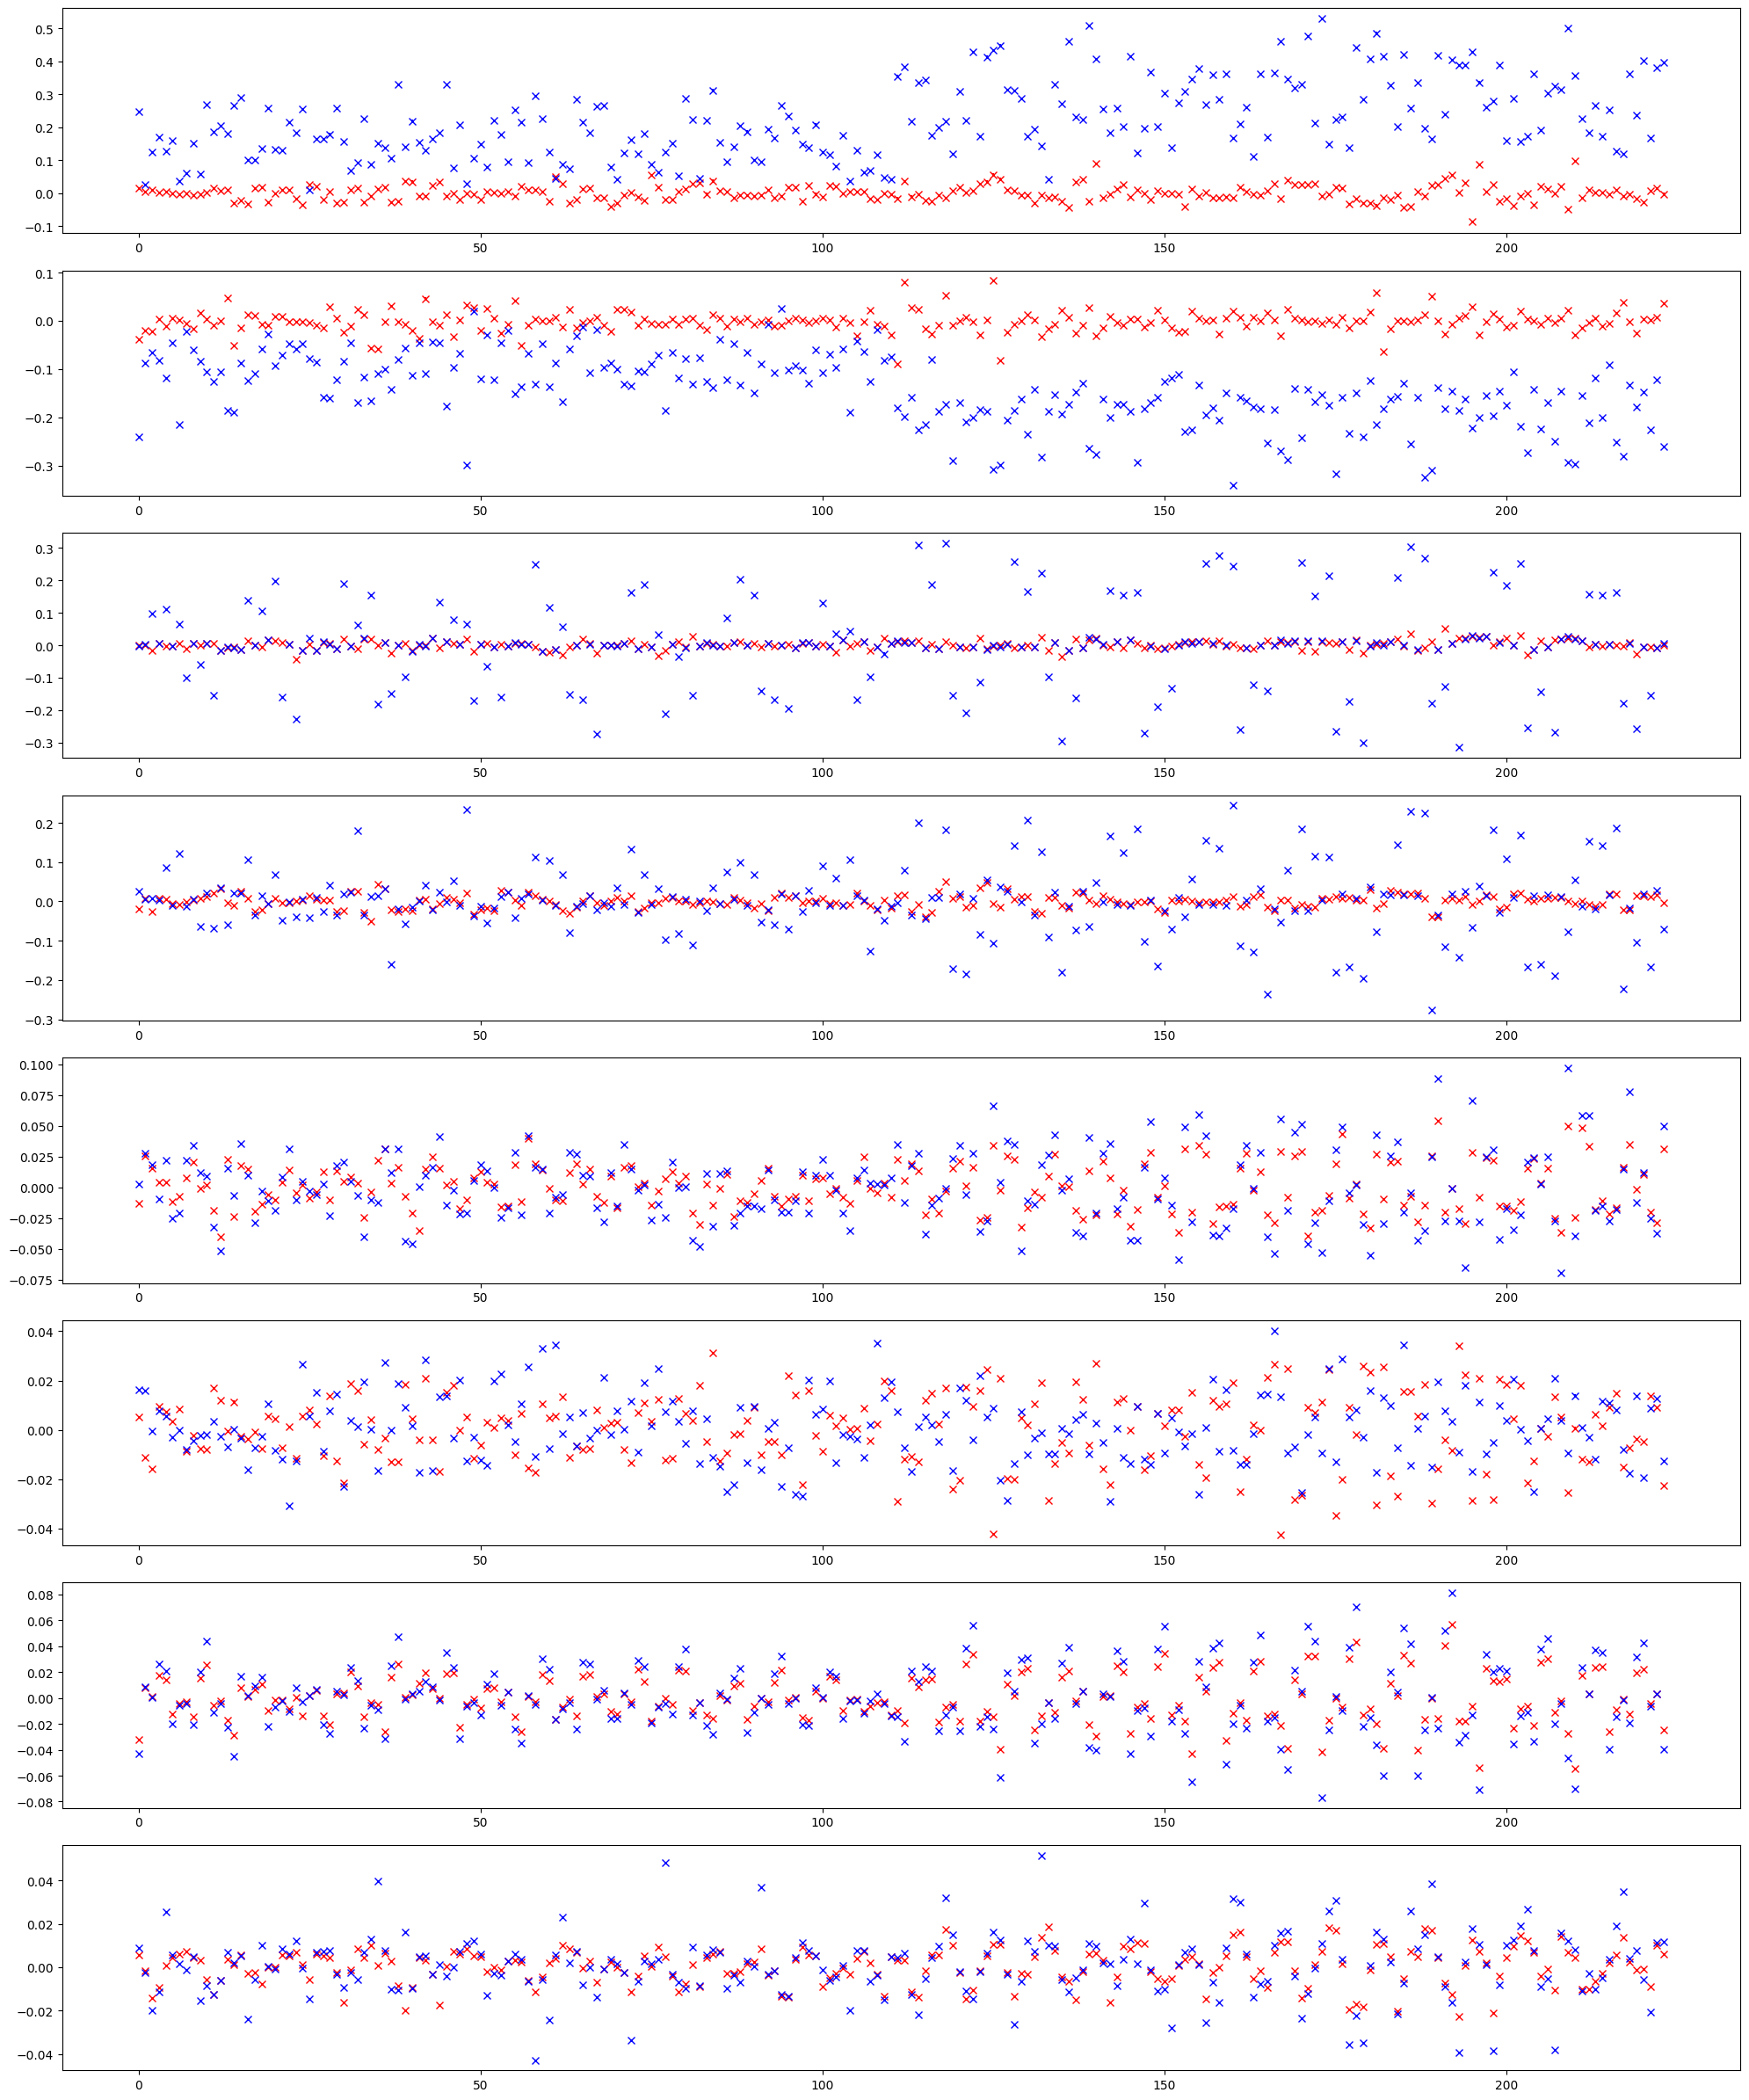

In [50]:
plt.figure(figsize=(20, 3*8))

ax = plt.subplot(811)
ax.errorbar(range(model.monitor_count), (n11 - value_n11).cpu().numpy(), yerr=error_n11.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n11_bpm - value_n11).cpu().numpy(), yerr=error_n11.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n11 - value_n11))
print(root_mean_square(n11_bpm - value_n11))
print()

ax = plt.subplot(812)
ax.errorbar(range(model.monitor_count), (n33 - value_n33).cpu().numpy(), yerr=error_n33.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n33_bpm - value_n33).cpu().numpy(), yerr=error_n33.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n33 - value_n33))
print(root_mean_square(n33_bpm - value_n33))
print()

ax = plt.subplot(813)
ax.errorbar(range(model.monitor_count), (n21 - value_n21).cpu().numpy(), yerr=error_n21.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n21_bpm - value_n21).cpu().numpy(), yerr=error_n21.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n21 - value_n21))
print(root_mean_square(n21_bpm - value_n21))
print()

ax = plt.subplot(814)
ax.errorbar(range(model.monitor_count), (n43 - value_n43).cpu().numpy(), yerr=error_n43.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n43_bpm - value_n43).cpu().numpy(), yerr=error_n43.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n43 - value_n43))
print(root_mean_square(n43_bpm - value_n43))
print()

ax = plt.subplot(815)
ax.errorbar(range(model.monitor_count), (n13 - value_n13).cpu().numpy(), yerr=error_n13.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n13_bpm - value_n13).cpu().numpy(), yerr=error_n13.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n13 - value_n13))
print(root_mean_square(n13_bpm - value_n13))
print()

ax = plt.subplot(816)
ax.errorbar(range(model.monitor_count), (n31 - value_n31).cpu().numpy(), yerr=error_n31.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n31_bpm - value_n31).cpu().numpy(), yerr=error_n31.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n31 - value_n31))
print(root_mean_square(n31_bpm - value_n31))
print()

ax = plt.subplot(817)
ax.errorbar(range(model.monitor_count), (n14 - value_n14).cpu().numpy(), yerr=error_n14.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n14_bpm - value_n14).cpu().numpy(), yerr=error_n14.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n14 - value_n14))
print(root_mean_square(n14_bpm - value_n14))
print()

ax = plt.subplot(818)
ax.errorbar(range(model.monitor_count), (n41 - value_n41).cpu().numpy(), yerr=error_n41.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n41_bpm - value_n41).cpu().numpy(), yerr=error_n41.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n41 - value_n41))
print(root_mean_square(n41_bpm - value_n41))
print()

plt.tight_layout()
plt.show()

In [51]:
# Estimate momenta at each monitor location

orbit = []
for location in range(model.monitor_count):
    orbit.append(twiss.get_momenta_lstsq(1, 256, location, 2, model.matrix))
orbit = torch.stack(orbit)
print(orbit.shape)

torch.Size([224, 4, 256])


In [52]:
# Use measured twiss to estimate invariants

s11, s33, s21, s43, s13, s31, s14, s41 = value.T
e11, e33, e21, e43, e13, e31, e14, e41 = error.T

BAG_IX = []
BAG_IY = []

for location in range(model.monitor_count):
    
    BAG_IX_MONITOR = []
    BAG_IY_MONITOR = []
    
    for _ in range(128):
        
        m11 = s11[location] + e11[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m33 = s33[location] + e33[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m21 = s21[location] + e21[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m43 = s43[location] + e43[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m13 = s13[location] + e13[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m31 = s31[location] + e31[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m14 = s14[location] + e14[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m41 = s41[location] + e41[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        
        normal = parametric_normal(m11, m33, m21, m43, m13, m31, m14, m41)
        
        QX, PX, QY, PY = normal.inverse() @ orbit[location]
        IX, IY = 0.5*(QX**2 + PX**2), 0.5*(QY**2 + PY**2)
        
        BAG_IX_MONITOR.append(IX)
        BAG_IY_MONITOR.append(IY)
        
    BAG_IX.append(BAG_IX_MONITOR)
    BAG_IY.append(BAG_IY_MONITOR)

BAG_IX = torch.stack([torch.stack(IX) for IX in BAG_IX]).reshape(model.monitor_count, -1)
BAG_IY = torch.stack([torch.stack(IY) for IY in BAG_IY]).reshape(model.monitor_count, -1)

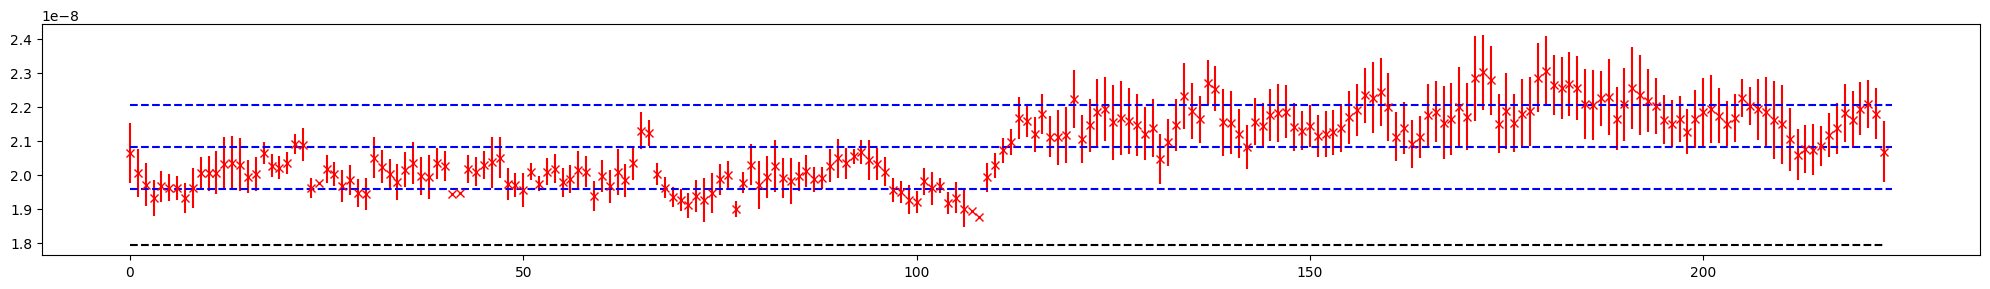

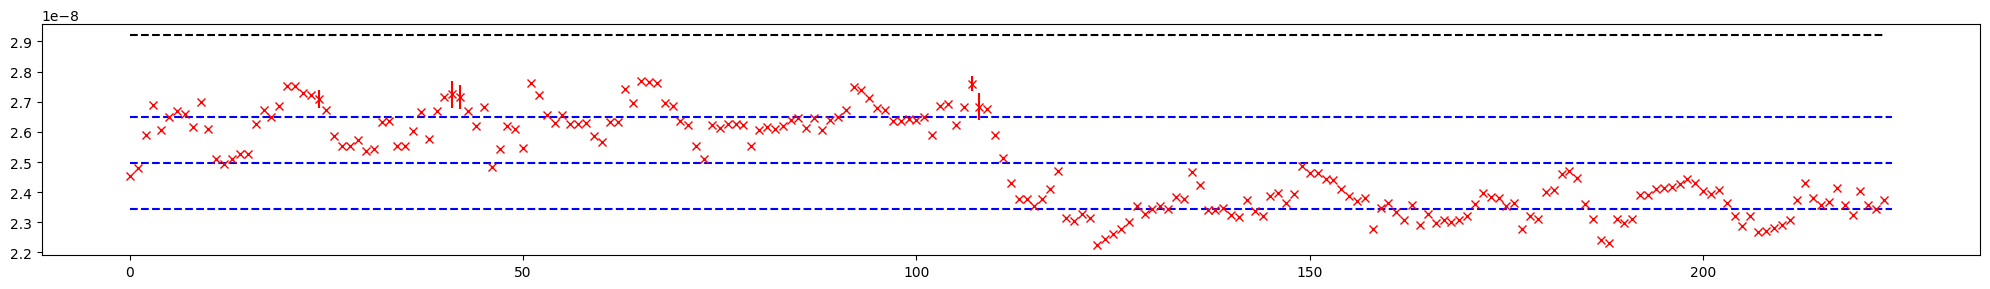

tensor(1.7944e-08, dtype=torch.float64)
tensor(2.0428e-08, dtype=torch.float64)
tensor(1.8848e-08, dtype=torch.float64)
tensor(2.0854e-08, dtype=torch.float64)
tensor(2.0818e-08, dtype=torch.float64)

tensor(2.9226e-08, dtype=torch.float64)
tensor(2.4982e-08, dtype=torch.float64)
tensor(2.4306e-08, dtype=torch.float64)
tensor(2.4962e-08, dtype=torch.float64)
tensor(2.4963e-08, dtype=torch.float64)



In [53]:
# Plot invariants for each monitor

plt.figure(figsize=(20, 3))
plt.errorbar(range(model.monitor_count), BAG_IX.mean(-1).flatten().cpu().numpy(), yerr=BAG_IX.std(-1).cpu().numpy(), fmt=' ', color='red', marker='x')

plt.hlines(ix.mean(), 0, model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.hlines([BAG_IX.mean() - BAG_IX.std(), BAG_IX.mean(), BAG_IX.mean() + BAG_IX.std()], 0, model.monitor_count, linestyles='dashed', color='blue')
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 3))
plt.errorbar(range(model.monitor_count), BAG_IY.mean(-1).flatten().cpu().numpy(), yerr=BAG_IY.std(-1).cpu().numpy(), fmt=' ', color='red', marker='x')
plt.hlines(iy.mean(), 0, model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.hlines([BAG_IY.mean() - BAG_IY.std(), BAG_IY.mean(), BAG_IY.mean() + BAG_IY.std()], 0, model.monitor_count, linestyles='dashed', color='blue')
plt.tight_layout()
plt.show()

print(ix.mean())
print(twiss.action['center_jx'])
print(invariant['ix_value'])
print(ix_out.mean())
print(BAG_IX.mean())
print()

print(iy.mean())
print(twiss.action['center_jy'])
print(invariant['iy_value'])
print(iy_out.mean())
print(BAG_IY.mean())
print()

In [54]:
%%time

# Estimate twiss from invariant fit (fixed invariants)

count = 8

data = twiss.get_twiss_from_data(1,                # -- first turn
                                 256,              # -- total number of turns, orbits are computed for (start, start + total)
                                 parametric_normal,# -- normalization
                                 model.matrix,     # -- transport matrix generator
                                 twiss=None,       # -- initial twiss for each location or None (use model values)
                                 method='lstsq',   # -- momenta computation method
                                 limit=2,          # -- range limit or direction/shift
                                 product=True,     # -- flag to use product objective
                                 jacobian=False,   # -- flag to use objective jacobian
                                 count=count,      # -- number of samples
                                 fraction=0.75,    # -- sample length fraction
                                 ix=BAG_IX.mean(), # -- ix invariant value
                                 iy=BAG_IY.mean(), # -- iy invariant value  (both should present for fixed fit)
                                 n_jobs=4,         # -- number of parallel jobs (loop over samples)
                                 verbose=False)    # -- verbose flag

CPU times: user 8min 37s, sys: 1min 44s, total: 10min 22s
Wall time: 13min 2s


In [55]:
# Process twiss

value_n11 = data[:, 0, 0]
error_n11 = data[:, 1, 0]

value_n33 = data[:, 0, 1]
error_n33 = data[:, 1, 1]

value_n21 = data[:, 0, 2]
error_n21 = data[:, 1, 2]

value_n43 = data[:, 0, 3]
error_n43 = data[:, 1, 3]

value_n13 = data[:, 0, 4]
error_n13 = data[:, 1, 4]

value_n31 = data[:, 0, 5]
error_n31 = data[:, 1, 5]

value_n14 = data[:, 0, 6]
error_n14 = data[:, 1, 6]

value_n41 = data[:, 0, 7]
error_n41 = data[:, 1, 7]

value_n11, error_n11 = twiss.process(value_n11, error_n11)
value_n33, error_n33 = twiss.process(value_n33, error_n33)
value_n21, error_n21 = twiss.process(value_n21, error_n21)
value_n43, error_n43 = twiss.process(value_n43, error_n43)
value_n13, error_n13 = twiss.process(value_n13, error_n13)
value_n31, error_n31 = twiss.process(value_n31, error_n31)
value_n14, error_n14 = twiss.process(value_n14, error_n14)
value_n41, error_n41 = twiss.process(value_n41, error_n41)

value = torch.stack([value_n11, value_n33, value_n21, value_n43, value_n13, value_n31, value_n14, value_n41]).T
error = torch.stack([error_n11, error_n33, error_n21, error_n43, error_n13, error_n31, error_n14, error_n41]).T

cs_value, cs_error = [], []

for value_loc, error_loc in zip(value, error):
    table = value_loc.reshape(-1, 1) + error_loc.reshape(-1, 1)*torch.randn(1024, dtype=dtype, device=device)
    table = torch.stack([parametric_normal(*free) for free in table.T])
    table = normal_to_wolski(table)
    table = torch.stack([wolski_to_cs(w) for w in table]).T
    cs_value.append(table.mean(-1))
    cs_error.append(table.std(-1))
    
cs_value = torch.stack(cs_value)
cs_error = torch.stack(cs_error)

value_ax, value_bx, value_ay, value_by = cs_value.T
error_ax, error_bx, error_ay, error_by = cs_error.T

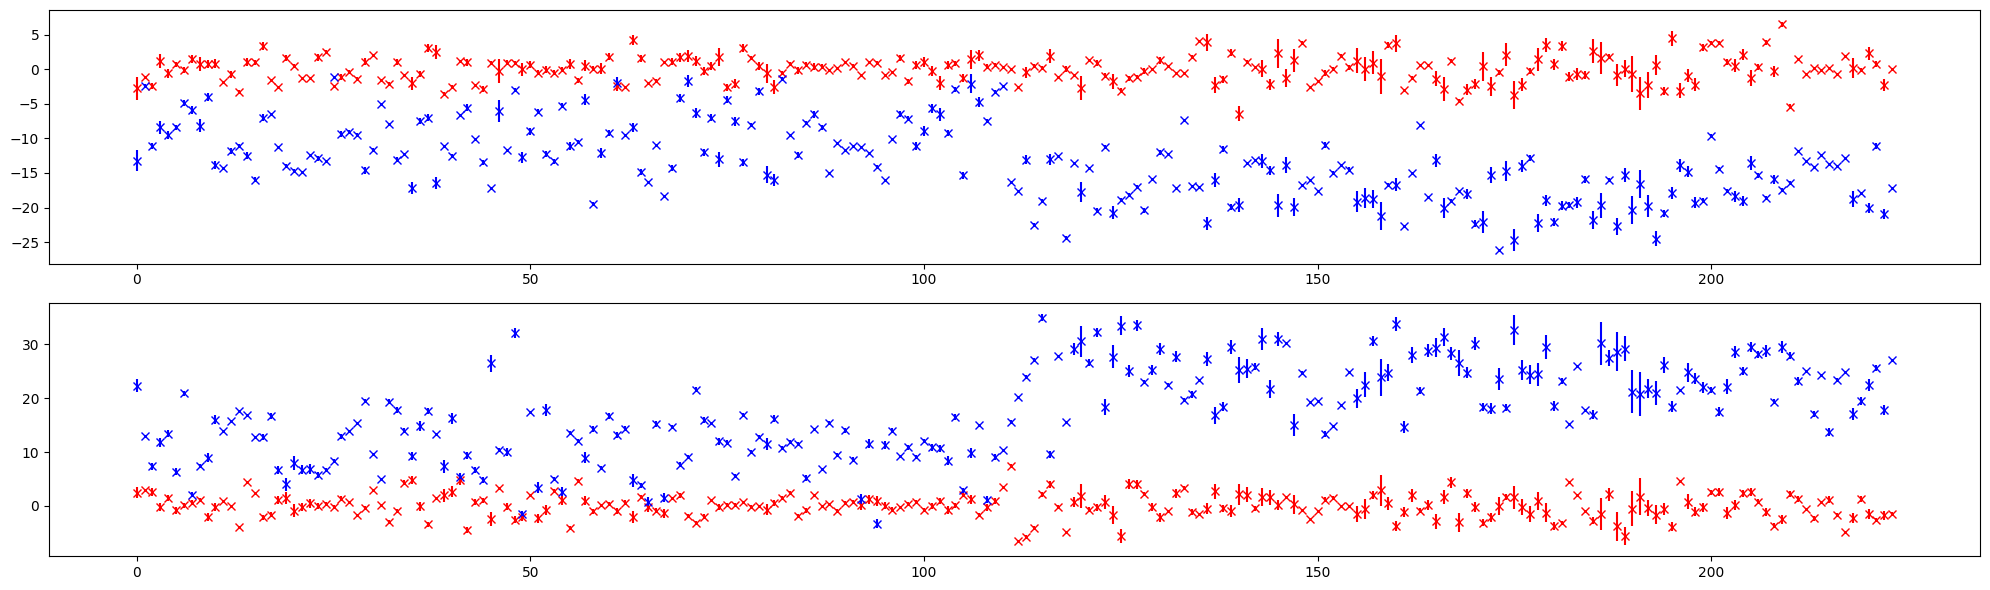

tensor(1.9126, dtype=torch.float64)
tensor(2.1975, dtype=torch.float64)

tensor(14.4554, dtype=torch.float64)
tensor(19.4827, dtype=torch.float64)



In [56]:
# Compare beta function values

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((value_bx - bx)/bx).cpu().numpy(), yerr=100/bx*error_bx.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((value_bx - bx_bpm)/bx_bpm).cpu().numpy(), yerr=100/bx_bpm*error_bx.cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((value_by - by)/by).cpu().numpy(), yerr=100/by*error_by.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((value_by - by_bpm)/by_bpm).cpu().numpy(), yerr=100/by_bpm*error_by.cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()

print(root_mean_square(100*((value_bx - bx)/bx)))
print(root_mean_square(100*((value_by - by)/by)))
print()

print(root_mean_square(100*((value_bx - bx_bpm)/bx_bpm)))
print(root_mean_square(100*((value_by - by_bpm)/by_bpm)))
print()

tensor(0.0304, dtype=torch.float64)
tensor(0.2502, dtype=torch.float64)

tensor(0.0237, dtype=torch.float64)
tensor(0.1614, dtype=torch.float64)

tensor(0.0167, dtype=torch.float64)
tensor(0.1213, dtype=torch.float64)

tensor(0.0176, dtype=torch.float64)
tensor(0.0903, dtype=torch.float64)

tensor(0.0477, dtype=torch.float64)
tensor(0.0472, dtype=torch.float64)

tensor(0.0318, dtype=torch.float64)
tensor(0.0370, dtype=torch.float64)

tensor(0.0476, dtype=torch.float64)
tensor(0.0471, dtype=torch.float64)

tensor(0.0169, dtype=torch.float64)
tensor(0.0199, dtype=torch.float64)



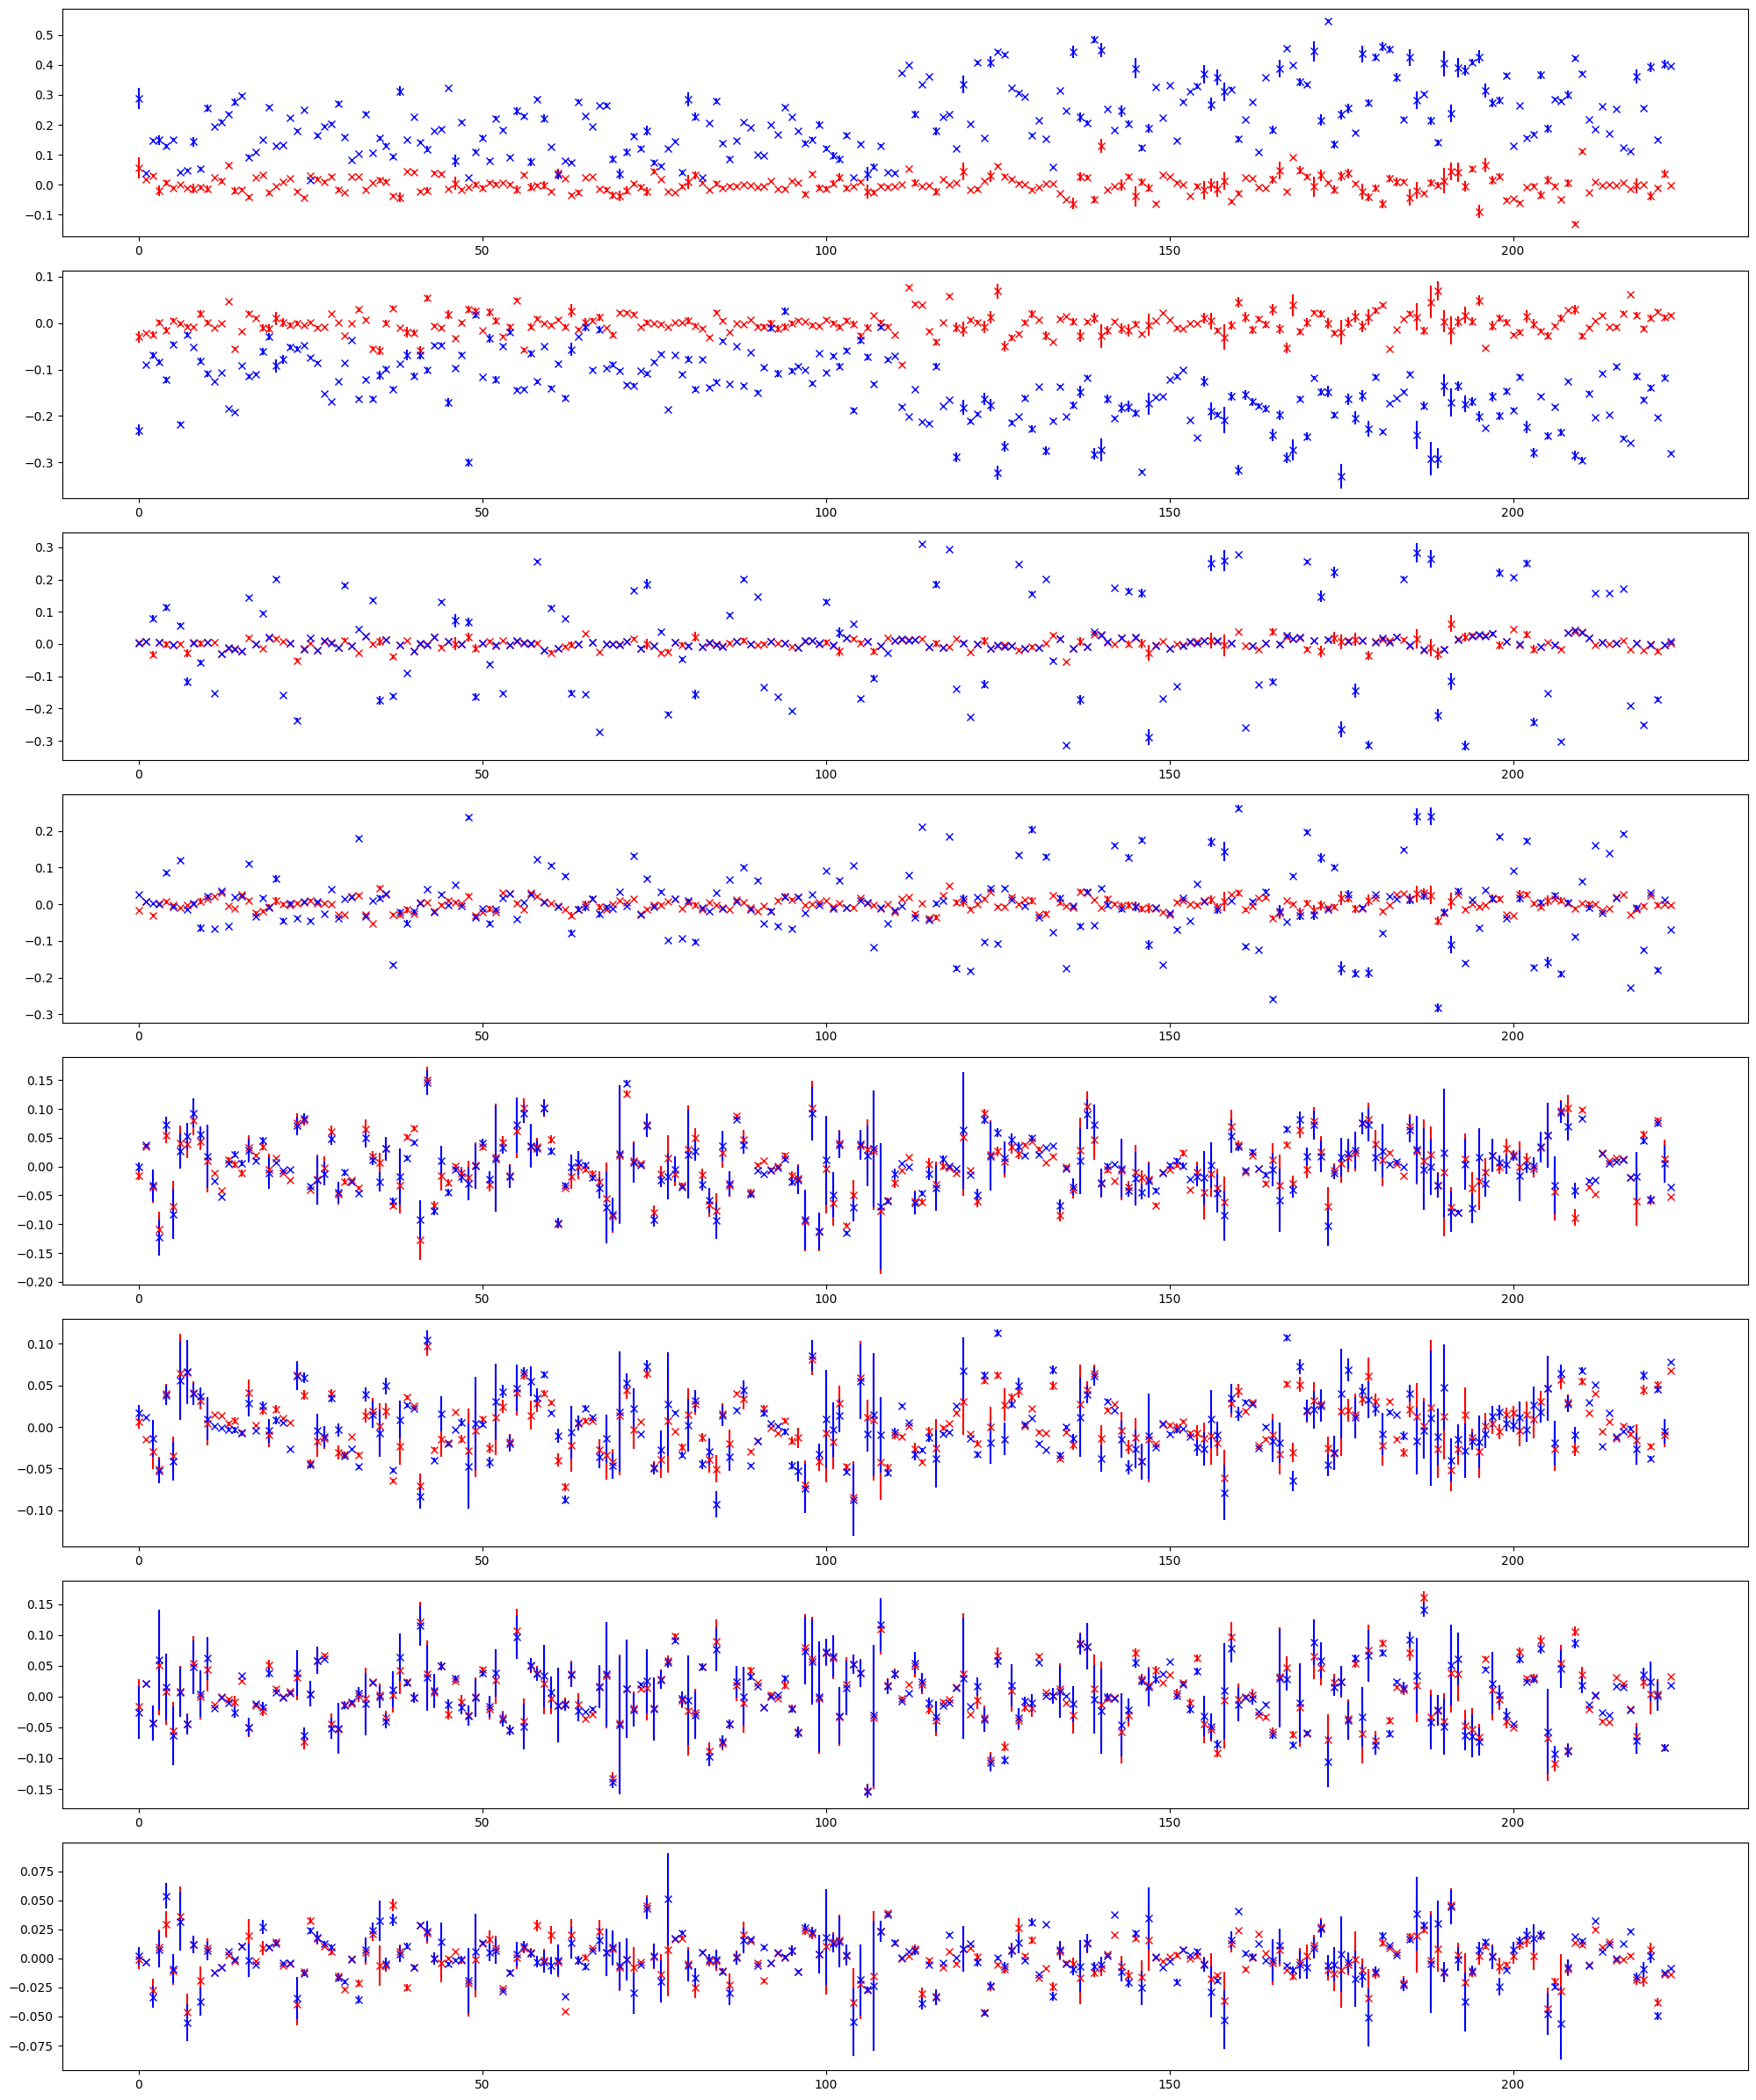

In [57]:
# Compare estimated normalization matrix elements

plt.figure(figsize=(20, 3*8))

ax = plt.subplot(811)
ax.errorbar(range(model.monitor_count), (n11 - value_n11).cpu().numpy(), yerr=error_n11.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n11_bpm - value_n11).cpu().numpy(), yerr=error_n11.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n11 - value_n11))
print(root_mean_square(n11_bpm - value_n11))
print()

ax = plt.subplot(812)
ax.errorbar(range(model.monitor_count), (n33 - value_n33).cpu().numpy(), yerr=error_n33.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n33_bpm - value_n33).cpu().numpy(), yerr=error_n33.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n33 - value_n33))
print(root_mean_square(n33_bpm - value_n33))
print()

ax = plt.subplot(813)
ax.errorbar(range(model.monitor_count), (n21 - value_n21).cpu().numpy(), yerr=error_n21.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n21_bpm - value_n21).cpu().numpy(), yerr=error_n21.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n21 - value_n21))
print(root_mean_square(n21_bpm - value_n21))
print()

ax = plt.subplot(814)
ax.errorbar(range(model.monitor_count), (n43 - value_n43).cpu().numpy(), yerr=error_n43.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n43_bpm - value_n43).cpu().numpy(), yerr=error_n43.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n43 - value_n43))
print(root_mean_square(n43_bpm - value_n43))
print()

ax = plt.subplot(815)
ax.errorbar(range(model.monitor_count), (n13 - value_n13).cpu().numpy(), yerr=error_n13.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n13_bpm - value_n13).cpu().numpy(), yerr=error_n13.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n13 - value_n13))
print(root_mean_square(n13_bpm - value_n13))
print()

ax = plt.subplot(816)
ax.errorbar(range(model.monitor_count), (n31 - value_n31).cpu().numpy(), yerr=error_n31.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n31_bpm - value_n31).cpu().numpy(), yerr=error_n31.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n31 - value_n31))
print(root_mean_square(n31_bpm - value_n31))
print()

ax = plt.subplot(817)
ax.errorbar(range(model.monitor_count), (n14 - value_n14).cpu().numpy(), yerr=error_n14.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n14_bpm - value_n14).cpu().numpy(), yerr=error_n14.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n14 - value_n14))
print(root_mean_square(n14_bpm - value_n14))
print()

ax = plt.subplot(818)
ax.errorbar(range(model.monitor_count), (n41 - value_n41).cpu().numpy(), yerr=error_n41.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n41_bpm - value_n41).cpu().numpy(), yerr=error_n41.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n41 - value_n41))
print(root_mean_square(n41_bpm - value_n41))
print()

plt.tight_layout()
plt.show()

In [58]:
# Estimate momenta at each monitor location

orbit = []
for location in range(model.monitor_count):
    orbit.append(twiss.get_momenta_lstsq(1, 256, location, 2, model.matrix))
orbit = torch.stack(orbit)
print(orbit.shape)

torch.Size([224, 4, 256])


In [59]:
# Use measured twiss to estimate invariants

s11, s33, s21, s43, s13, s31, s14, s41 = value.T
e11, e33, e21, e43, e13, e31, e14, e41 = error.T

BAG_IX = []
BAG_IY = []

for location in range(model.monitor_count):
    
    BAG_IX_MONITOR = []
    BAG_IY_MONITOR = []
    
    for _ in range(128):
        
        m11 = s11[location] + e11[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m33 = s33[location] + e33[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m21 = s21[location] + e21[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m43 = s43[location] + e43[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m13 = s13[location] + e13[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m31 = s31[location] + e31[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m14 = s14[location] + e14[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m41 = s41[location] + e41[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        
        normal = parametric_normal(m11, m33, m21, m43, m13, m31, m14, m41)
        
        QX, PX, QY, PY = normal.inverse() @ orbit[location]
        IX, IY = 0.5*(QX**2 + PX**2), 0.5*(QY**2 + PY**2)
        
        BAG_IX_MONITOR.append(IX)
        BAG_IY_MONITOR.append(IY)
        
    BAG_IX.append(BAG_IX_MONITOR)
    BAG_IY.append(BAG_IY_MONITOR)

BAG_IX = torch.stack([torch.stack(IX) for IX in BAG_IX]).reshape(model.monitor_count, -1)
BAG_IY = torch.stack([torch.stack(IY) for IY in BAG_IY]).reshape(model.monitor_count, -1)

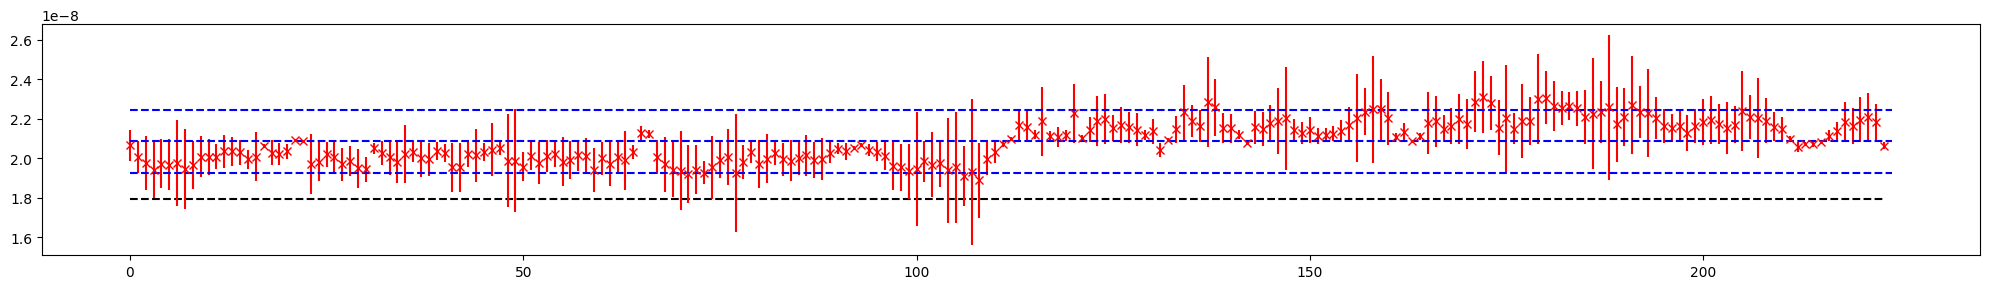

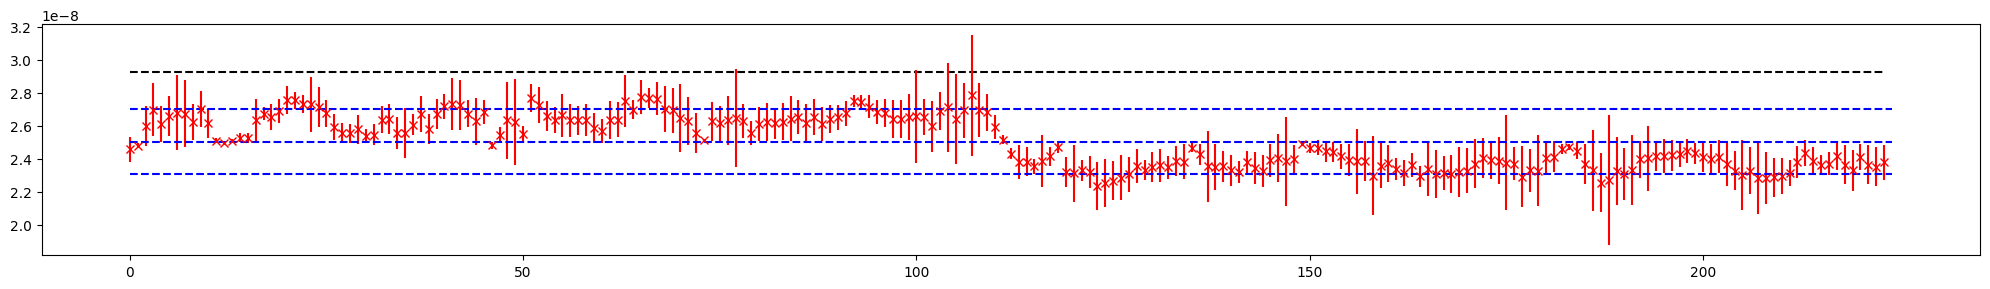

tensor(1.7944e-08, dtype=torch.float64)
tensor(2.0428e-08, dtype=torch.float64)
tensor(1.8848e-08, dtype=torch.float64)
tensor(2.0846e-08, dtype=torch.float64)

tensor(2.9226e-08, dtype=torch.float64)
tensor(2.4982e-08, dtype=torch.float64)
tensor(2.4306e-08, dtype=torch.float64)
tensor(2.5024e-08, dtype=torch.float64)



In [60]:
# Plot invariants for each monitor

plt.figure(figsize=(20, 3))
plt.errorbar(range(model.monitor_count), BAG_IX.mean(-1).flatten().cpu().numpy(), yerr=BAG_IX.std(-1).cpu().numpy(), fmt=' ', color='red', marker='x')

plt.hlines(ix.mean(), 0, model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.hlines([BAG_IX.mean() - BAG_IX.std(), BAG_IX.mean(), BAG_IX.mean() + BAG_IX.std()], 0, model.monitor_count, linestyles='dashed', color='blue')
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 3))
plt.errorbar(range(model.monitor_count), BAG_IY.mean(-1).flatten().cpu().numpy(), yerr=BAG_IY.std(-1).cpu().numpy(), fmt=' ', color='red', marker='x')
plt.hlines(iy.mean(), 0, model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.hlines([BAG_IY.mean() - BAG_IY.std(), BAG_IY.mean(), BAG_IY.mean() + BAG_IY.std()], 0, model.monitor_count, linestyles='dashed', color='blue')
plt.tight_layout()
plt.show()

print(ix.mean())
print(twiss.action['center_jx'])
print(invariant['ix_value'])
print(BAG_IX.mean())
print()

print(iy.mean())
print(twiss.action['center_jy'])
print(invariant['iy_value'])
print(BAG_IY.mean())
print()

## Scale calibrations (twiss ration)

In [61]:
# Set twiss

twiss = Twiss(model, table_bpm, limit=4)

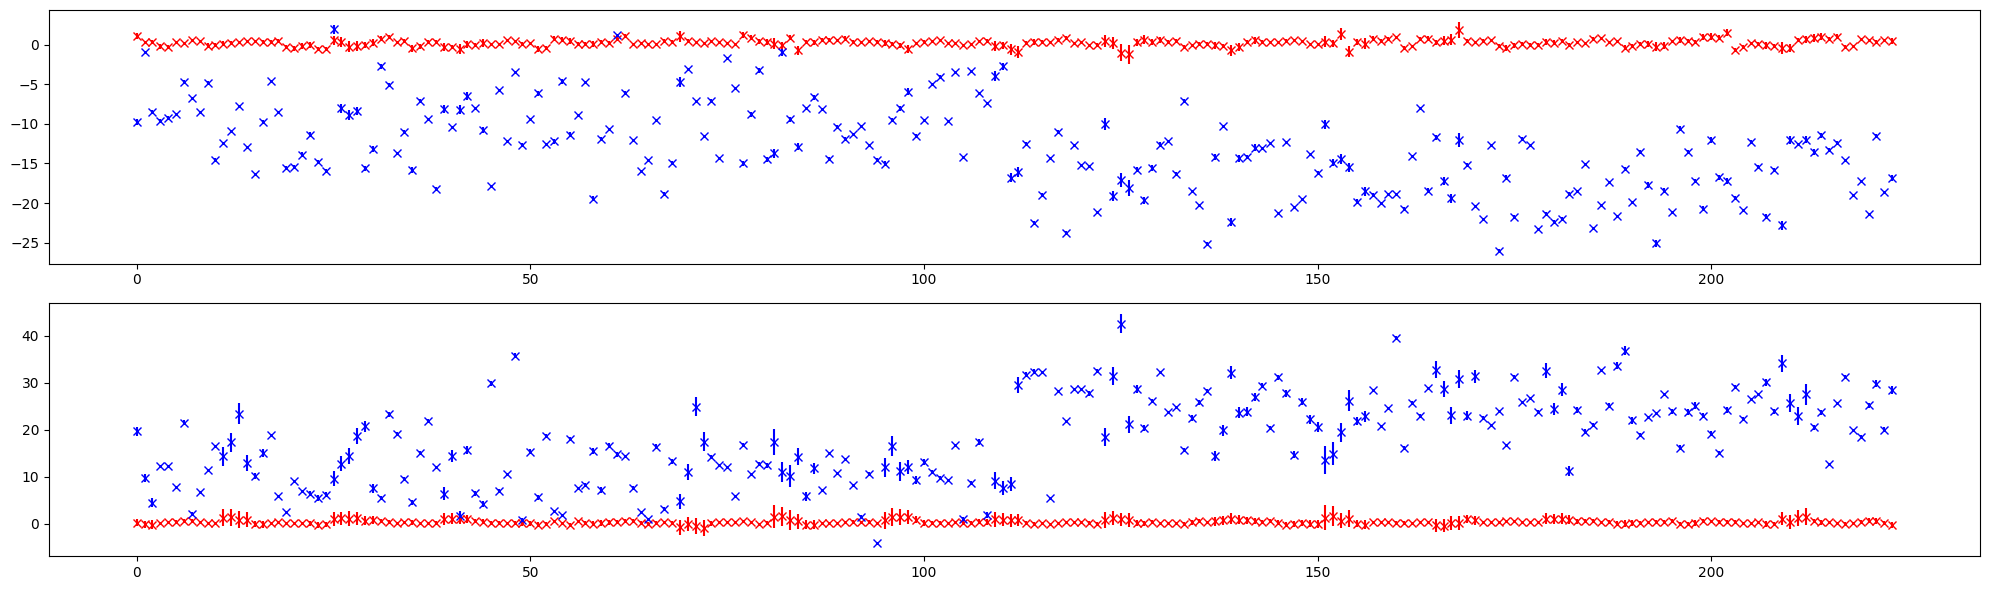

tensor(0.5119, dtype=torch.float64)
tensor(0.5837, dtype=torch.float64)

tensor(14.3156, dtype=torch.float64)
tensor(20.2609, dtype=torch.float64)



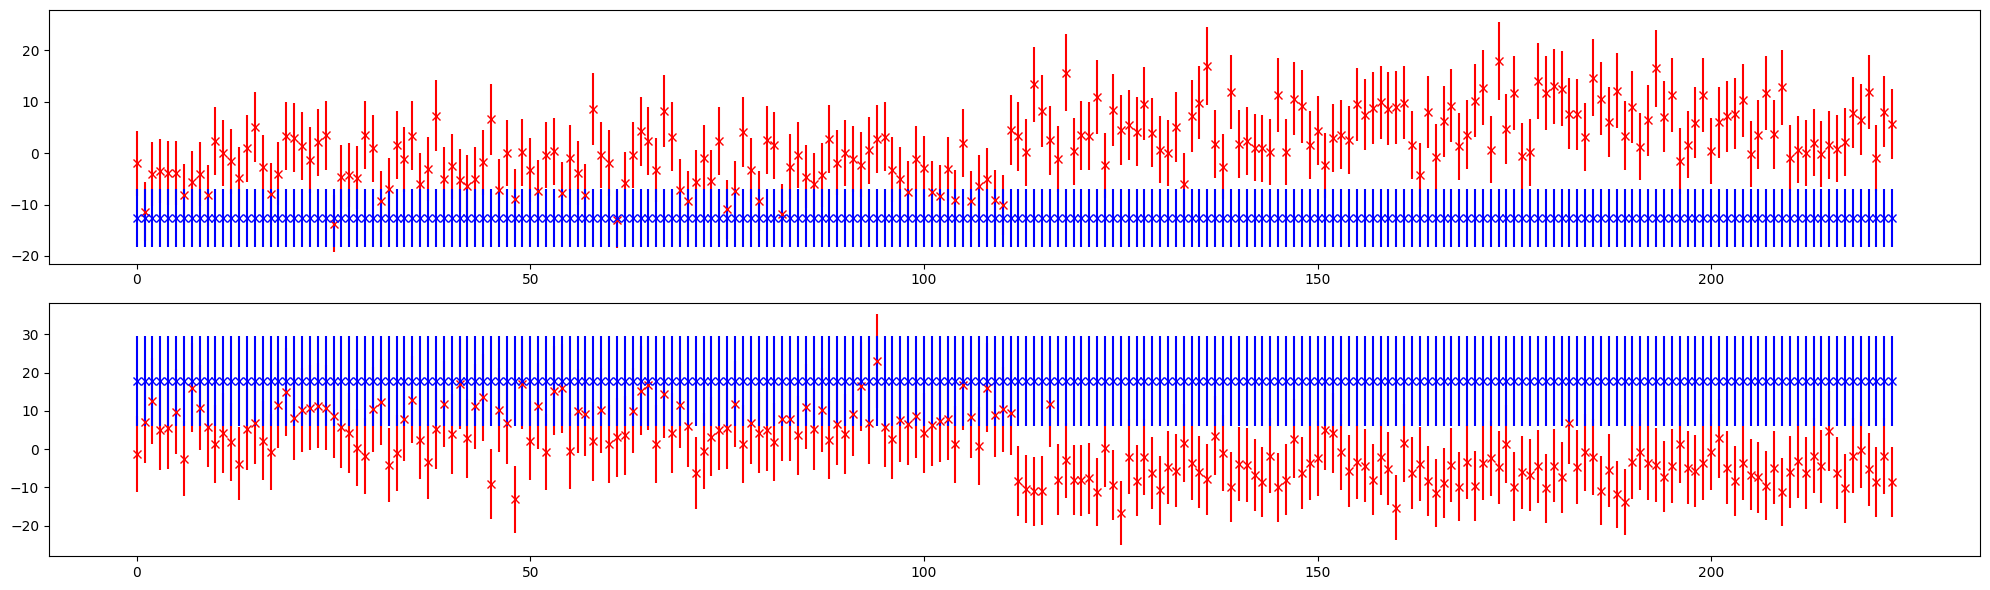

tensor(6.6419, dtype=torch.float64)
tensor(7.9426, dtype=torch.float64)

tensor(12.5467, dtype=torch.float64)
tensor(17.7400, dtype=torch.float64)



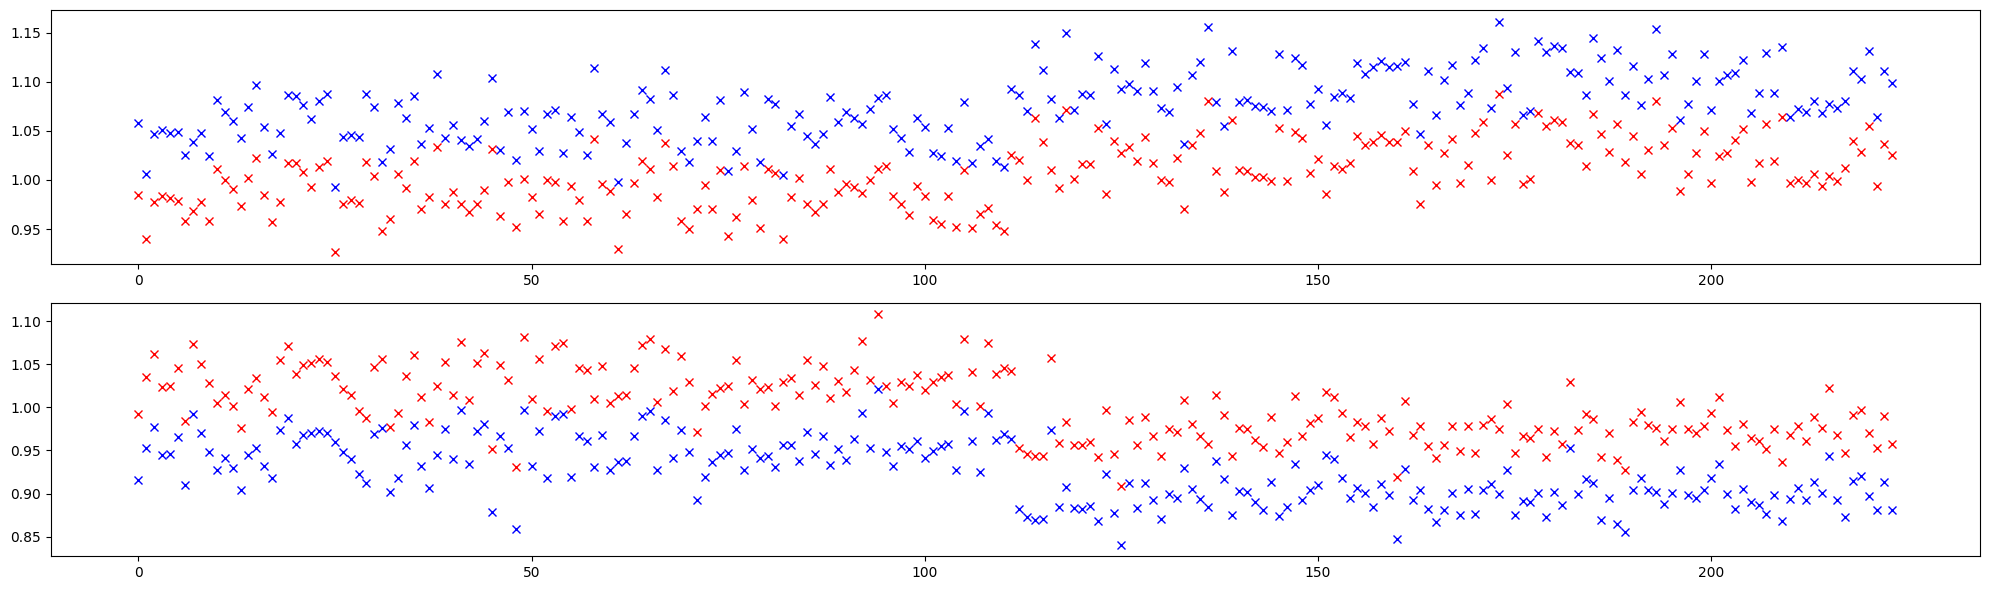

tensor(6.6019, dtype=torch.float64)
tensor(8.2964, dtype=torch.float64)



In [62]:
# Ratio (invariants from model twiss)


twiss.phase_virtual()
twiss.get_twiss_from_phase()
mask_x = twiss.filter_twiss(plane='x', phase={'use': True, 'threshold': 10.0}, model={'use': False, 'threshold': 0.5}, value={'use': False, 'threshold': 0.5}, sigma={'use': False, 'threshold': 0.25}, limit={'use': True, 'threshold': 5.0})
mask_y = twiss.filter_twiss(plane='y', phase={'use': True, 'threshold': 10.0}, model={'use': False, 'threshold': 0.5}, value={'use': False, 'threshold': 0.5}, sigma={'use': False, 'threshold': 0.25}, limit={'use': True, 'threshold': 5.0})
_ = twiss.process_twiss(plane='x', mask=mask_x, weight=True)
_ = twiss.process_twiss(plane='y', mask=mask_y, weight=True)

twiss.get_action()
twiss.get_twiss_from_amplitude()

# Twiss (phase)

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((twiss.bx[model.monitor_index] - bx)/bx).cpu().numpy(), yerr=100/bx*twiss.sigma_bx[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((twiss.bx[model.monitor_index] - bx_bpm)/bx_bpm).cpu().numpy(), yerr=100/bx_bpm*twiss.sigma_bx[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((twiss.by[model.monitor_index] - by)/by).cpu().numpy(), yerr=100/by*twiss.sigma_by[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((twiss.by[model.monitor_index] - by_bpm)/by_bpm).cpu().numpy(), yerr=100/by_bpm*twiss.sigma_by[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()
print(root_mean_square(100*((twiss.bx[model.monitor_index] - bx)/bx)))
print(root_mean_square(100*((twiss.by[model.monitor_index] - by)/by)))
print()
print(root_mean_square(100*((twiss.bx[model.monitor_index] - bx_bpm)/bx_bpm)))
print(root_mean_square(100*((twiss.by[model.monitor_index] - by_bpm)/by_bpm)))
print()

# Twiss (amplitude)

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['bx'] - bx)/bx).cpu().numpy(), yerr=100/bx*twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['bx'] - bx_bpm)/bx_bpm).cpu().numpy(), yerr=100/bx_bpm*twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['by'] - by)/by).cpu().numpy(), yerr=100/by*twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['by'] - by_bpm)/by_bpm).cpu().numpy(), yerr=100/by_bpm*twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()
print(root_mean_square(100*((twiss.data_amplitude['bx'] - bx)/bx)))
print(root_mean_square(100*((twiss.data_amplitude['by'] - by)/by)))
print()
print(root_mean_square(100*((twiss.data_amplitude['bx'] - bx_bpm)/bx_bpm)))
print(root_mean_square(100*((twiss.data_amplitude['by'] - by_bpm)/by_bpm)))
print()

# Ratio

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), (twiss.data_amplitude['bx']/twiss.bx[model.monitor_index]).sqrt().cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), g_xx.cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), (twiss.data_amplitude['by']/twiss.by[model.monitor_index]).sqrt().cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), g_yy.cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()

print(root_mean_square(100*(((twiss.data_amplitude['bx']/twiss.bx[model.monitor_index]).sqrt() - g_xx)/g_xx)))
print(root_mean_square(100*(((twiss.data_amplitude['by']/twiss.by[model.monitor_index]).sqrt() - g_yy)/g_yy)))
print()

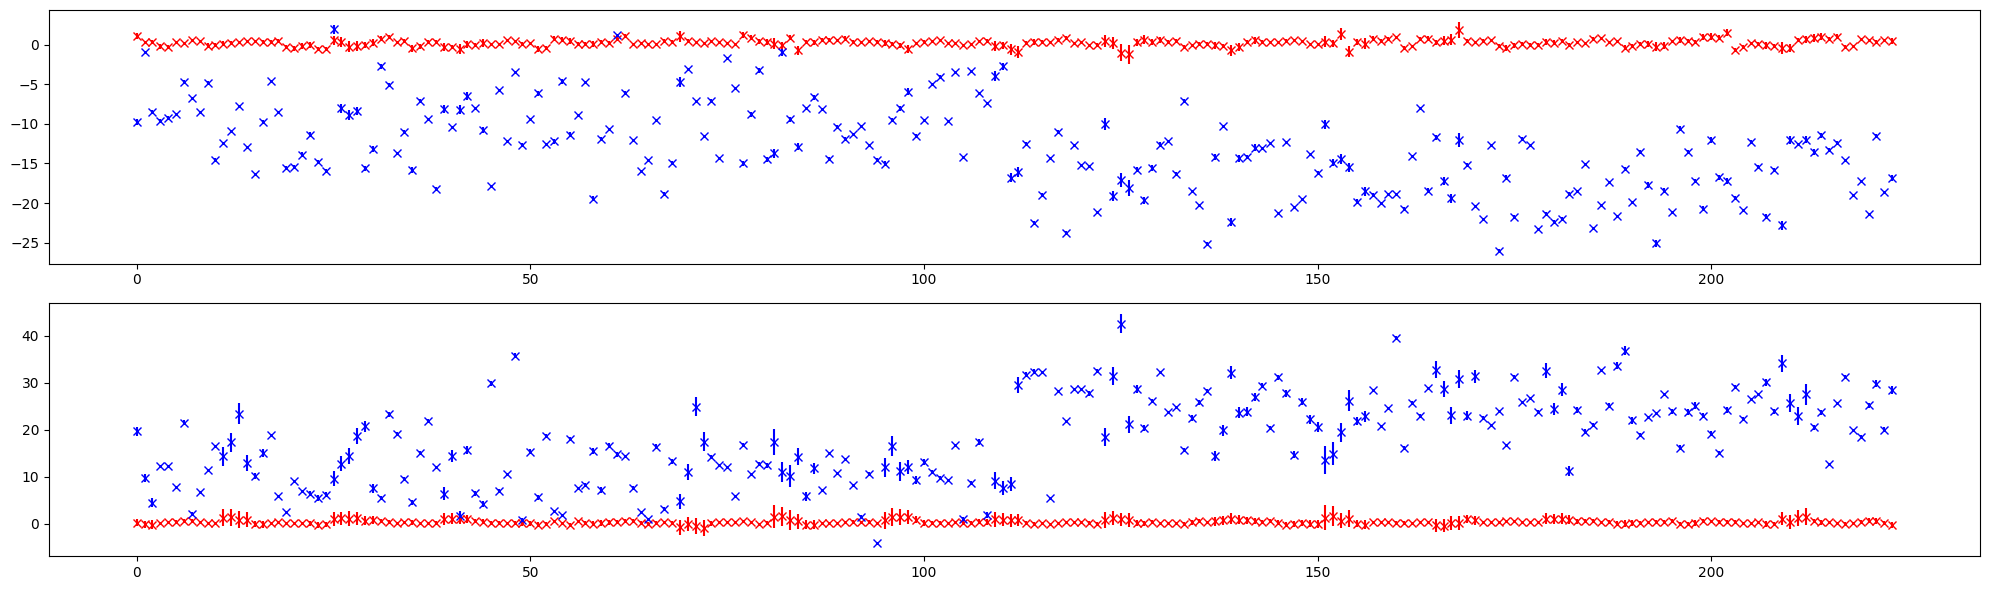

tensor(0.5119, dtype=torch.float64)
tensor(0.5837, dtype=torch.float64)

tensor(14.3156, dtype=torch.float64)
tensor(20.2609, dtype=torch.float64)



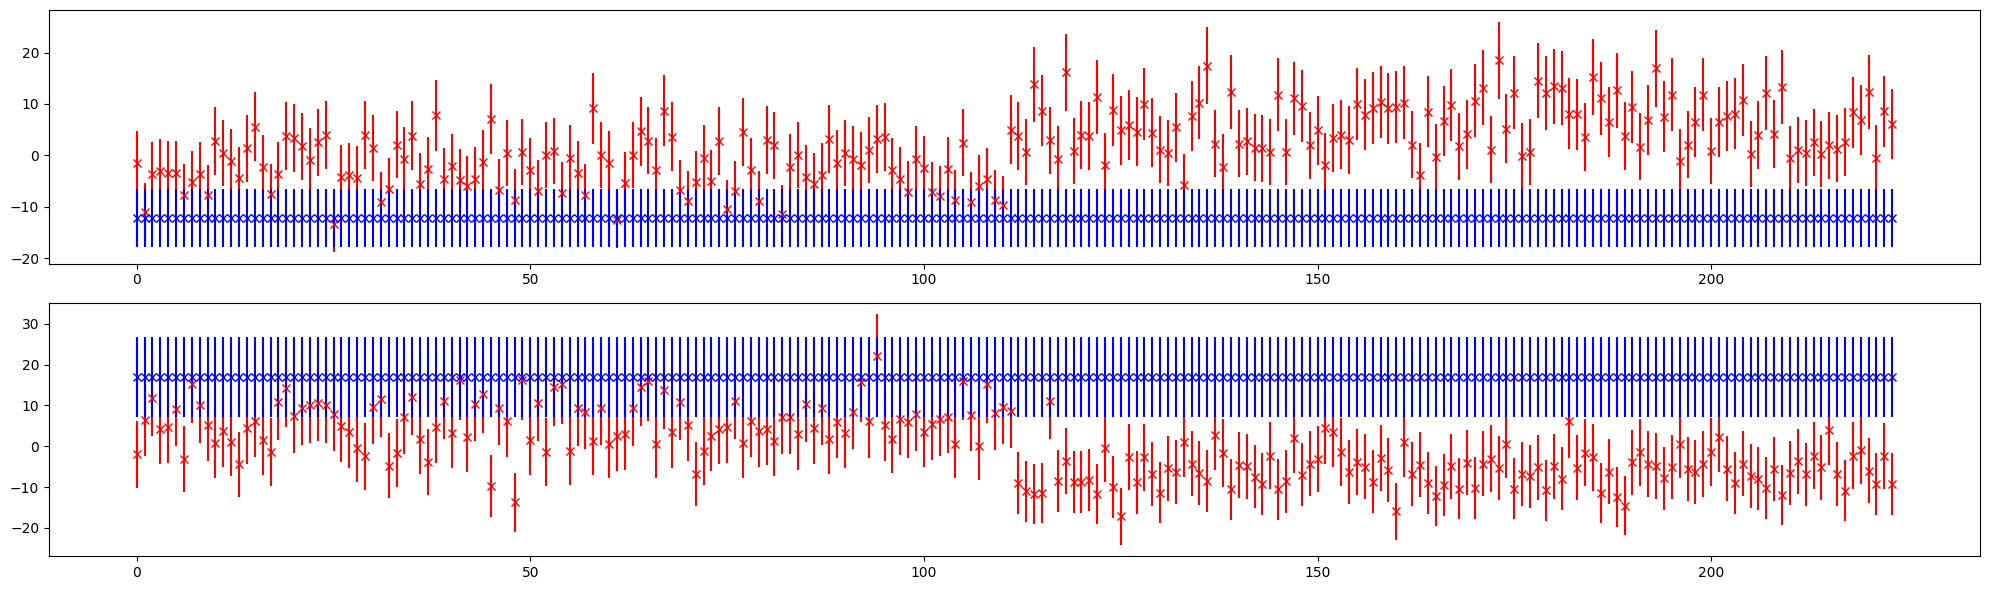

tensor(6.7784, dtype=torch.float64)
tensor(7.8582, dtype=torch.float64)

tensor(12.1596, dtype=torch.float64)
tensor(16.9869, dtype=torch.float64)



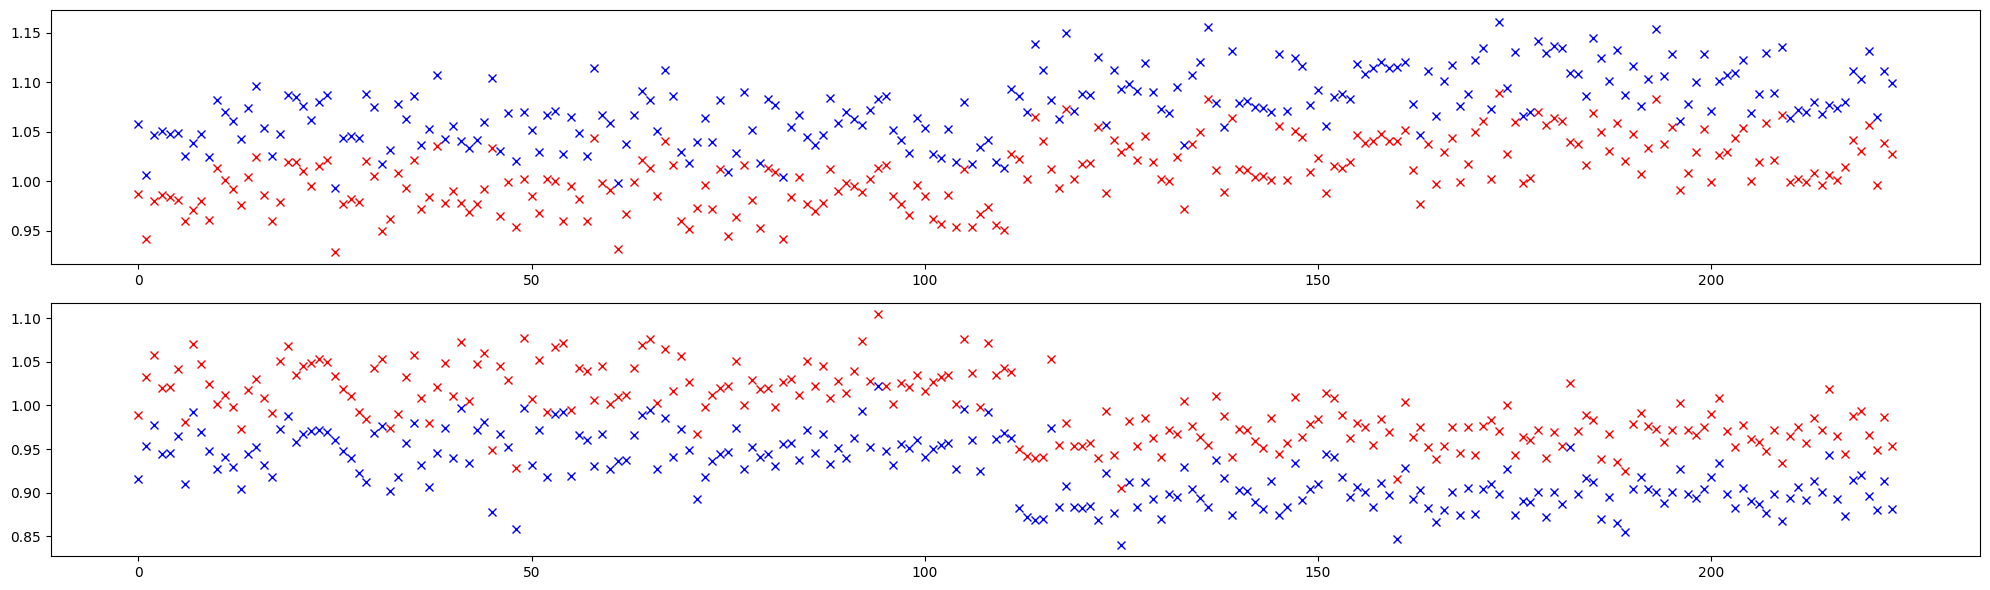

tensor(6.3955, dtype=torch.float64)
tensor(7.9497, dtype=torch.float64)



In [63]:
# Ratio (invariants from phase twiss)

twiss = Twiss(model, table_bpm, limit=4)

twiss.phase_virtual()
twiss.get_twiss_from_phase()
mask_x = twiss.filter_twiss(plane='x', phase={'use': True, 'threshold': 10.0}, model={'use': False, 'threshold': 0.5}, value={'use': False, 'threshold': 0.5}, sigma={'use': False, 'threshold': 0.25}, limit={'use': True, 'threshold': 5.0})
mask_y = twiss.filter_twiss(plane='y', phase={'use': True, 'threshold': 10.0}, model={'use': False, 'threshold': 0.5}, value={'use': False, 'threshold': 0.5}, sigma={'use': False, 'threshold': 0.25}, limit={'use': True, 'threshold': 5.0})
_ = twiss.process_twiss(plane='x', mask=mask_x, weight=True)
_ = twiss.process_twiss(plane='y', mask=mask_y, weight=True)

twiss.get_action(bx=twiss.bx[model.monitor_index], by=twiss.by[model.monitor_index], sigma_bx=twiss.sigma_bx[model.monitor_index], sigma_by=twiss.sigma_by[model.monitor_index])
twiss.get_twiss_from_amplitude()

# Twiss (phase)

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((twiss.bx[model.monitor_index] - bx)/bx).cpu().numpy(), yerr=100/bx*twiss.sigma_bx[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((twiss.bx[model.monitor_index] - bx_bpm)/bx_bpm).cpu().numpy(), yerr=100/bx_bpm*twiss.sigma_bx[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((twiss.by[model.monitor_index] - by)/by).cpu().numpy(), yerr=100/by*twiss.sigma_by[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((twiss.by[model.monitor_index] - by_bpm)/by_bpm).cpu().numpy(), yerr=100/by_bpm*twiss.sigma_by[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()
print(root_mean_square(100*((twiss.bx[model.monitor_index] - bx)/bx)))
print(root_mean_square(100*((twiss.by[model.monitor_index] - by)/by)))
print()
print(root_mean_square(100*((twiss.bx[model.monitor_index] - bx_bpm)/bx_bpm)))
print(root_mean_square(100*((twiss.by[model.monitor_index] - by_bpm)/by_bpm)))
print()

# Twiss (amplitude)

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['bx'] - bx)/bx).cpu().numpy(), yerr=100/bx*twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['bx'] - bx_bpm)/bx_bpm).cpu().numpy(), yerr=100/bx_bpm*twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['by'] - by)/by).cpu().numpy(), yerr=100/by*twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['by'] - by_bpm)/by_bpm).cpu().numpy(), yerr=100/by_bpm*twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()
print(root_mean_square(100*((twiss.data_amplitude['bx'] - bx)/bx)))
print(root_mean_square(100*((twiss.data_amplitude['by'] - by)/by)))
print()
print(root_mean_square(100*((twiss.data_amplitude['bx'] - bx_bpm)/bx_bpm)))
print(root_mean_square(100*((twiss.data_amplitude['by'] - by_bpm)/by_bpm)))
print()

# Ratio

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), (twiss.data_amplitude['bx']/twiss.bx[model.monitor_index]).sqrt().cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), g_xx.cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), (twiss.data_amplitude['by']/twiss.by[model.monitor_index]).sqrt().cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), g_yy.cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()

gxx_phase = (twiss.data_amplitude['bx']/twiss.bx[model.monitor_index]).sqrt()
gyy_phase = (twiss.data_amplitude['by']/twiss.by[model.monitor_index]).sqrt()

print(root_mean_square(100*(((twiss.data_amplitude['bx']/twiss.bx[model.monitor_index]).sqrt() - g_xx)/g_xx)))
print(root_mean_square(100*(((twiss.data_amplitude['by']/twiss.by[model.monitor_index]).sqrt() - g_yy)/g_yy)))
print()

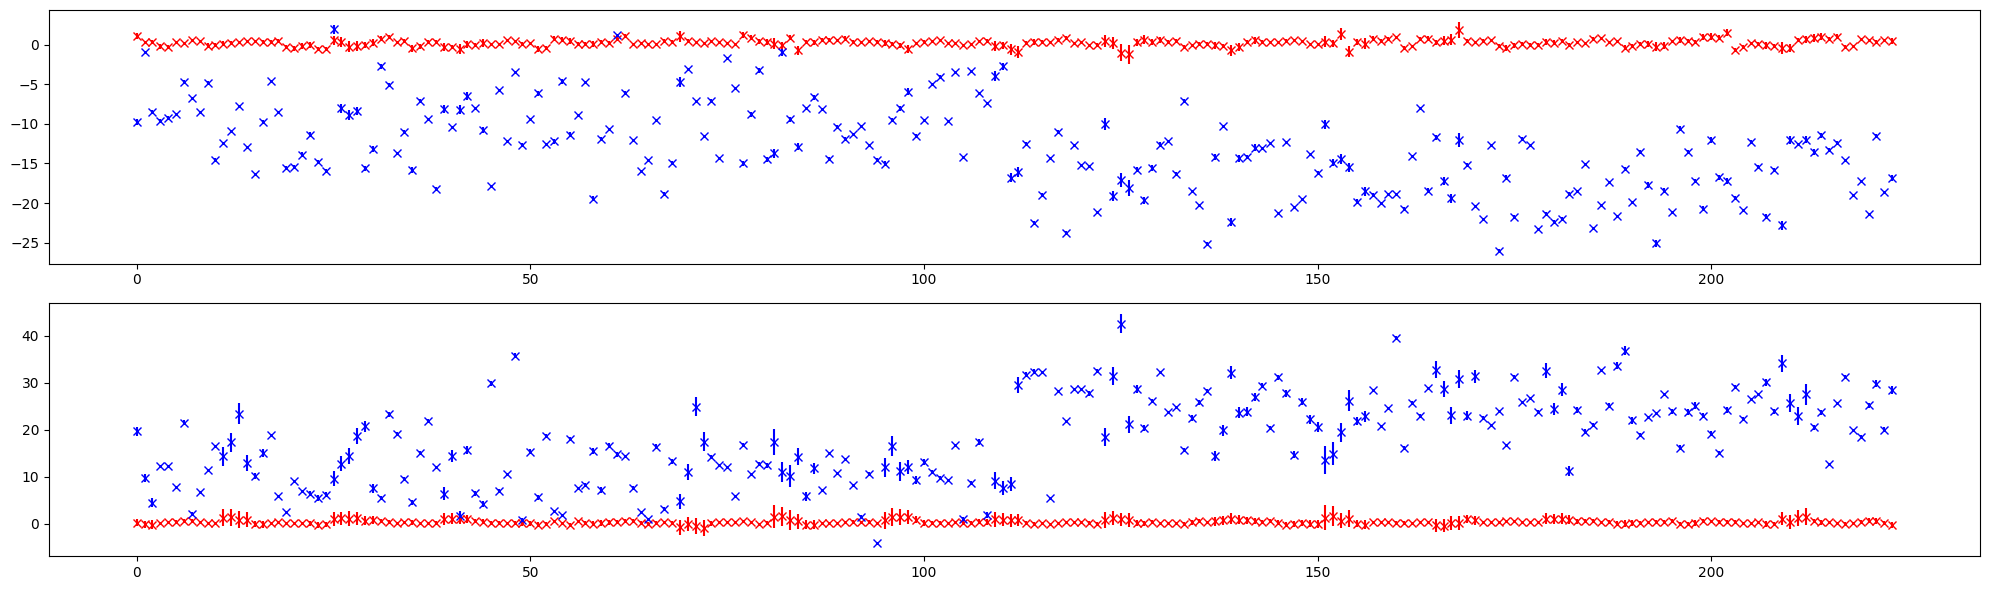

tensor(0.5119, dtype=torch.float64)
tensor(0.5837, dtype=torch.float64)

tensor(14.3156, dtype=torch.float64)
tensor(20.2609, dtype=torch.float64)



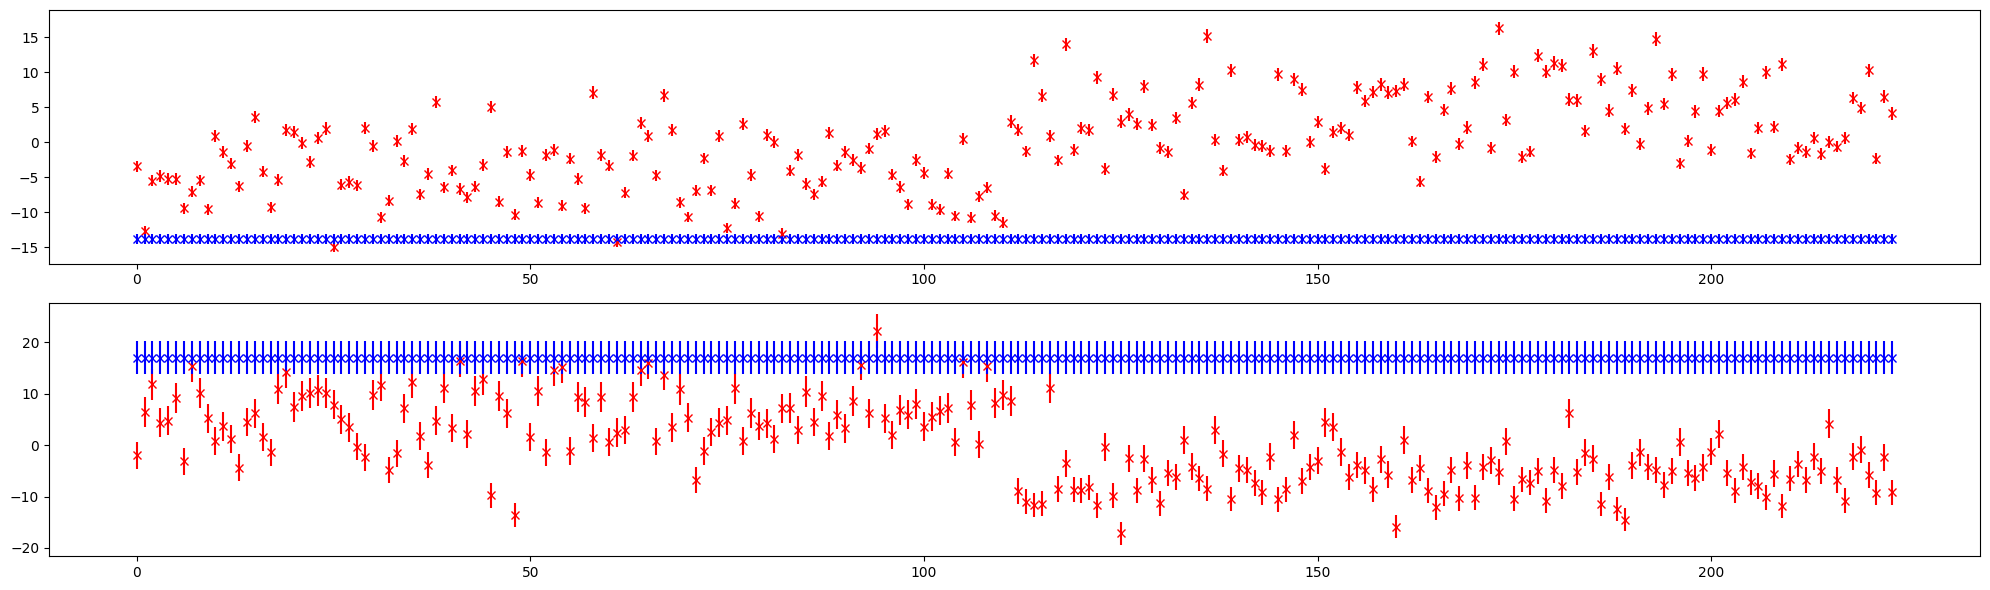

tensor(6.3989, dtype=torch.float64)
tensor(7.8635, dtype=torch.float64)

tensor(13.8146, dtype=torch.float64)
tensor(17.0532, dtype=torch.float64)



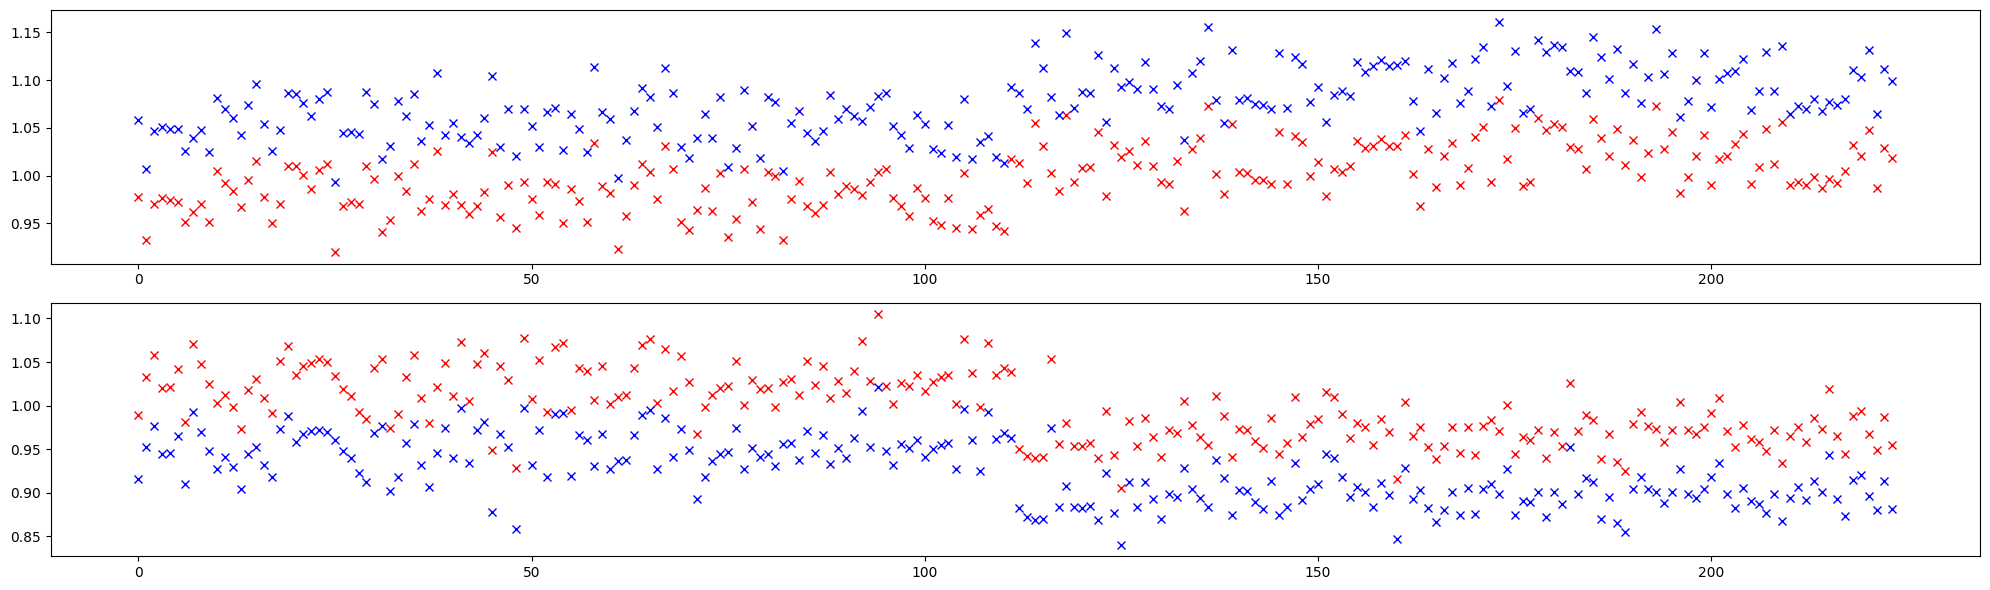

tensor(7.2811, dtype=torch.float64)
tensor(7.9802, dtype=torch.float64)



In [64]:
# Ratio (fitted invariants)

twiss.phase_virtual()
twiss.get_twiss_from_phase()
mask_x = twiss.filter_twiss(plane='x', phase={'use': True, 'threshold': 10.0}, model={'use': False, 'threshold': 0.5}, value={'use': False, 'threshold': 0.5}, sigma={'use': False, 'threshold': 0.25}, limit={'use': True, 'threshold': 5.0})
mask_y = twiss.filter_twiss(plane='y', phase={'use': True, 'threshold': 10.0}, model={'use': False, 'threshold': 0.5}, value={'use': False, 'threshold': 0.5}, sigma={'use': False, 'threshold': 0.25}, limit={'use': True, 'threshold': 5.0})
_ = twiss.process_twiss(plane='x', mask=mask_x, weight=True)
_ = twiss.process_twiss(plane='y', mask=mask_y, weight=True)

twiss.get_action(jx=BAG_IX.mean(-1), jy=BAG_IY.mean(-1), sigma_jx=BAG_IX.std(-1), sigma_jy=BAG_IY.std(-1))
twiss.get_twiss_from_amplitude()

# Twiss (phase)

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((twiss.bx[model.monitor_index] - bx)/bx).cpu().numpy(), yerr=100/bx*twiss.sigma_bx[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((twiss.bx[model.monitor_index] - bx_bpm)/bx_bpm).cpu().numpy(), yerr=100/bx_bpm*twiss.sigma_bx[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((twiss.by[model.monitor_index] - by)/by).cpu().numpy(), yerr=100/by*twiss.sigma_by[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((twiss.by[model.monitor_index] - by_bpm)/by_bpm).cpu().numpy(), yerr=100/by_bpm*twiss.sigma_by[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()
print(root_mean_square(100*((twiss.bx[model.monitor_index] - bx)/bx)))
print(root_mean_square(100*((twiss.by[model.monitor_index] - by)/by)))
print()
print(root_mean_square(100*((twiss.bx[model.monitor_index] - bx_bpm)/bx_bpm)))
print(root_mean_square(100*((twiss.by[model.monitor_index] - by_bpm)/by_bpm)))
print()

# Twiss (amplitude)

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['bx'] - bx)/bx).cpu().numpy(), yerr=100/bx*twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['bx'] - bx_bpm)/bx_bpm).cpu().numpy(), yerr=100/bx_bpm*twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['by'] - by)/by).cpu().numpy(), yerr=100/by*twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['by'] - by_bpm)/by_bpm).cpu().numpy(), yerr=100/by_bpm*twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()
print(root_mean_square(100*((twiss.data_amplitude['bx'] - bx)/bx)))
print(root_mean_square(100*((twiss.data_amplitude['by'] - by)/by)))
print()
print(root_mean_square(100*((twiss.data_amplitude['bx'] - bx_bpm)/bx_bpm)))
print(root_mean_square(100*((twiss.data_amplitude['by'] - by_bpm)/by_bpm)))
print()

# Ratio

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), (twiss.data_amplitude['bx']/twiss.bx[model.monitor_index]).sqrt().cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), g_xx.cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), (twiss.data_amplitude['by']/twiss.by[model.monitor_index]).sqrt().cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), g_yy.cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()

print(root_mean_square(100*(((twiss.data_amplitude['bx']/twiss.bx[model.monitor_index]).sqrt() - g_xx)/g_xx)))
print(root_mean_square(100*(((twiss.data_amplitude['by']/twiss.by[model.monitor_index]).sqrt() - g_yy)/g_yy)))
print()

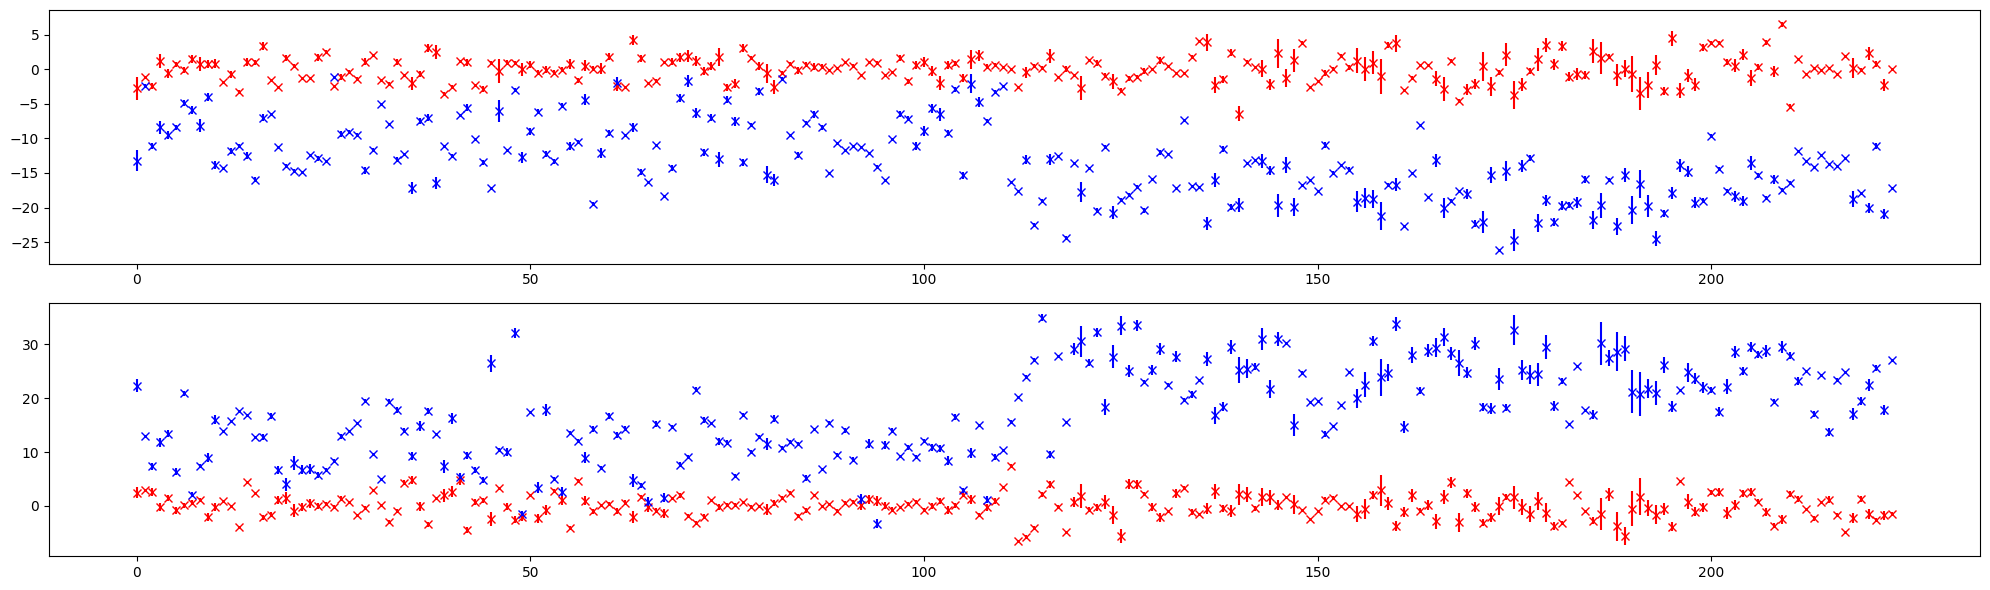

tensor(1.9126, dtype=torch.float64)
tensor(2.1975, dtype=torch.float64)

tensor(14.4554, dtype=torch.float64)
tensor(19.4827, dtype=torch.float64)



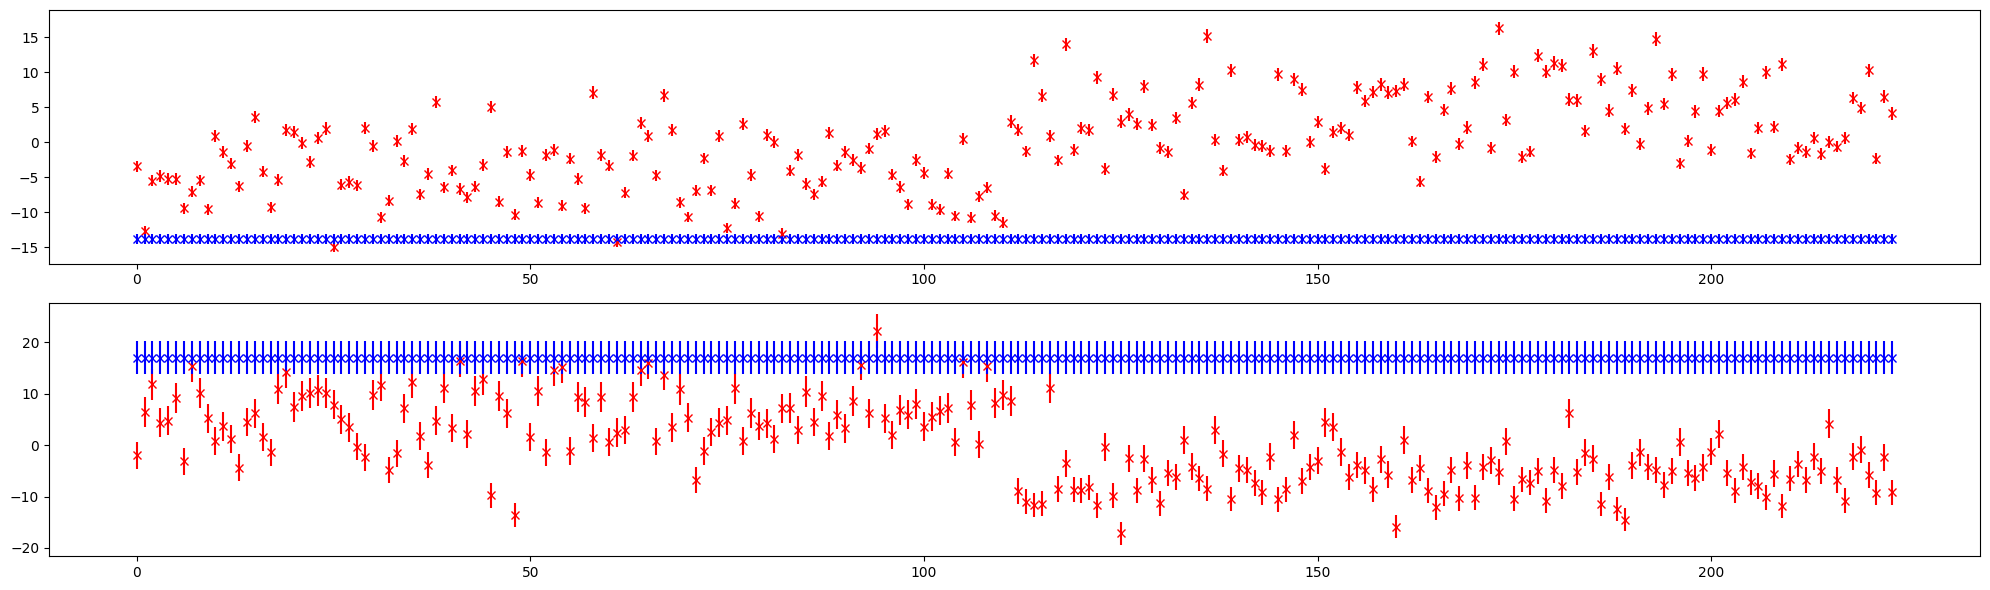

tensor(6.3989, dtype=torch.float64)
tensor(7.8635, dtype=torch.float64)

tensor(13.8146, dtype=torch.float64)
tensor(17.0532, dtype=torch.float64)



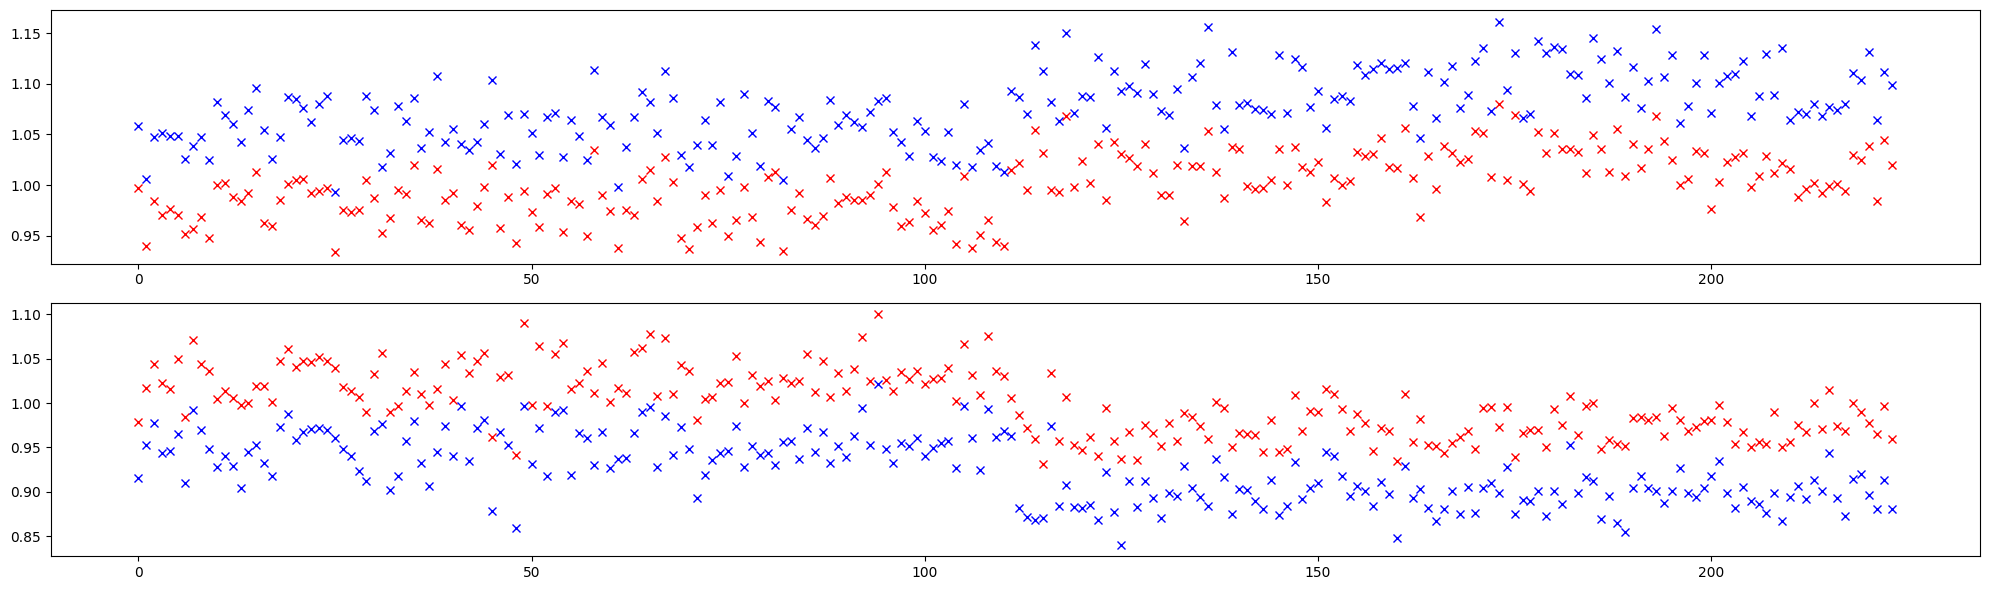

tensor(7.2063, dtype=torch.float64)
tensor(8.2709, dtype=torch.float64)



In [65]:
# Ratio (fitted invariants and fitted beta functions)

twiss.phase_virtual()
twiss.get_twiss_from_phase()
mask_x = twiss.filter_twiss(plane='x', phase={'use': True, 'threshold': 10.0}, model={'use': False, 'threshold': 0.5}, value={'use': False, 'threshold': 0.5}, sigma={'use': False, 'threshold': 0.25}, limit={'use': True, 'threshold': 5.0})
mask_y = twiss.filter_twiss(plane='y', phase={'use': True, 'threshold': 10.0}, model={'use': False, 'threshold': 0.5}, value={'use': False, 'threshold': 0.5}, sigma={'use': False, 'threshold': 0.25}, limit={'use': True, 'threshold': 5.0})
_ = twiss.process_twiss(plane='x', mask=mask_x, weight=True)
_ = twiss.process_twiss(plane='y', mask=mask_y, weight=True)

twiss.get_action(jx=BAG_IX.mean(-1), jy=BAG_IY.mean(-1), sigma_jx=BAG_IX.std(-1), sigma_jy=BAG_IY.std(-1))
twiss.get_twiss_from_amplitude()

# Twiss (fit)

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((value_bx - bx)/bx).cpu().numpy(), yerr=100/bx*error_bx.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((value_bx - bx_bpm)/bx_bpm).cpu().numpy(), yerr=100/bx_bpm*error_bx.cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((value_by - by)/by).cpu().numpy(), yerr=100/by*error_by.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((value_by - by_bpm)/by_bpm).cpu().numpy(), yerr=100/by_bpm*error_by.cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()
print(root_mean_square(100*((value_bx - bx)/bx)))
print(root_mean_square(100*((value_by - by)/by)))
print()
print(root_mean_square(100*((value_bx - bx_bpm)/bx_bpm)))
print(root_mean_square(100*((value_by - by_bpm)/by_bpm)))
print()

# Twiss (amplitude)

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['bx'] - bx)/bx).cpu().numpy(), yerr=100/bx*twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['bx'] - bx_bpm)/bx_bpm).cpu().numpy(), yerr=100/bx_bpm*twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['by'] - by)/by).cpu().numpy(), yerr=100/by*twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['by'] - by_bpm)/by_bpm).cpu().numpy(), yerr=100/by_bpm*twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()
print(root_mean_square(100*((twiss.data_amplitude['bx'] - bx)/bx)))
print(root_mean_square(100*((twiss.data_amplitude['by'] - by)/by)))
print()
print(root_mean_square(100*((twiss.data_amplitude['bx'] - bx_bpm)/bx_bpm)))
print(root_mean_square(100*((twiss.data_amplitude['by'] - by_bpm)/by_bpm)))
print()

# Ratio

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), (twiss.data_amplitude['bx']/value_bx).sqrt().cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), g_xx.cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), (twiss.data_amplitude['by']/value_by).sqrt().cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), g_yy.cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()

print(root_mean_square(100*(((twiss.data_amplitude['bx']/value_bx).sqrt() - g_xx)/g_xx)))
print(root_mean_square(100*(((twiss.data_amplitude['by']/value_by).sqrt() - g_yy)/g_yy)))
print()

In [66]:
# If all BPMs have the same systematic shift in sacle calibrations
# Both ration of beta functions and fitted invarint will have systematic shift
# If only a small group of BPMs are systematicaly shifted, fitted invariants are expected to be accurate
# Thus, estimated calibration scales will be meaningful